# PF Optimization: HRP vs Markowitz and Equal-Weighted Positions

## Imports & Settings

> This notebook requires the `conda` environment `backtest`. Please see the [installation instructions](../installation/README.md) for running the latest Docker image or alternative ways to set up your environment.

In [47]:
from time import time
import warnings
import sys

from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas_datareader.data as web

from logbook import (NestedSetup, NullHandler, Logger, 
                     StreamHandler, StderrHandler, 
                     INFO, WARNING, DEBUG, ERROR)

from zipline import run_algorithm
from zipline.api import (attach_pipeline, pipeline_output,
                         date_rules, time_rules, record,get_datetime,
                         schedule_function, commission, slippage,
                         set_slippage, set_commission, set_max_leverage,
                         order_target, order_target_percent,
                         get_open_orders, cancel_order)
from zipline.data import bundles
from zipline.utils.run_algo import load_extensions
from zipline.pipeline import Pipeline, CustomFactor
from zipline.pipeline.data import Column, DataSet
from zipline.pipeline.domain import US_EQUITIES
from zipline.pipeline.filters import StaticAssets
from zipline.pipeline.loaders.frame import DataFrameLoader

from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt.hierarchical_portfolio import HRPOpt
from pypfopt import risk_models
from pypfopt import expected_returns

import pyfolio as pf
from pyfolio.plotting import plot_rolling_returns, plot_rolling_sharpe
from pyfolio.timeseries import forecast_cone_bootstrap

In [48]:
sns.set_style('darkgrid')
warnings.filterwarnings('ignore')
np.random.seed(42)

### Load zipline extensions

Only need this in notebook to find bundle.

In [49]:
load_extensions(default=True,
                extensions=[],
                strict=True,
                environ=None)

### Logging Setup

In [50]:
# setup stdout logging
format_string = '[{record.time: %H:%M:%S.%f}]: {record.level_name}: {record.message}'
zipline_logging = NestedSetup([NullHandler(level=DEBUG),
                               StreamHandler(sys.stdout, format_string=format_string, level=INFO),
                               StreamHandler(sys.stdout, format_string=format_string, level=WARNING),
                               StreamHandler(sys.stderr, level=ERROR)])
zipline_logging.push_application()
log = Logger('Algorithm')

## Algo Params

In [51]:
N_LONGS = 25
MIN_POSITIONS = 20

## Load Data

### Quandl Wiki Bundel

In [52]:
bundle_data = bundles.load('quandl')

### ML Predictions

In [53]:
def load_predictions(bundle):
    path = Path('../../12_gradient_boosting_machines/data')
    predictions = (pd.concat([pd.read_hdf(path / 'predictions.h5', 'lgb/train/01'),
                              pd.read_hdf(path / 'predictions.h5', 'lgb/test/01').drop('y_test', axis=1)]))
    predictions = (predictions.loc[~predictions.index.duplicated()]
                   .iloc[:, :10]
                   .mean(1)
                   .sort_index()
                   .dropna()
                  .to_frame('prediction'))
    tickers = predictions.index.get_level_values('symbol').unique().tolist()

    assets = bundle.asset_finder.lookup_symbols(tickers, as_of_date=None)
    predicted_sids = pd.Index([asset.sid for asset in assets], dtype='int64')
    ticker_map = dict(zip(tickers, predicted_sids))

    return (predictions
            .unstack('symbol')
            .rename(columns=ticker_map)
            .prediction
            ), assets

In [54]:
predictions, assets = load_predictions(bundle_data)

In [55]:
predictions.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 753 entries, 2015-01-02 to 2017-12-28
Columns: 995 entries, 0 to 3188
dtypes: float64(995)
memory usage: 5.7 MB


### Define Custom Dataset

In [56]:
class SignalData(DataSet):
    predictions = Column(dtype=float)
    domain = US_EQUITIES

### Define Pipeline Loaders

In [57]:
signal_loader = {SignalData.predictions:
                     DataFrameLoader(SignalData.predictions, predictions)}

## Pipeline Setup

### Custom ML Factor

In [58]:
class MLSignal(CustomFactor):
    """Converting signals to Factor
        so we can rank and filter in Pipeline"""
    inputs = [SignalData.predictions]
    window_length = 1

    def compute(self, today, assets, out, predictions):
        out[:] = predictions

### Create Pipeline

In [59]:
def compute_signals():
    signals = MLSignal()
    return Pipeline(columns={
        'longs' : signals.top(N_LONGS, mask=signals > 0)
    },
            screen=StaticAssets(assets))

### Get daily Pipeline results

In [60]:
def before_trading_start(context, data):
    """
    Called every day before market open.
    """
    output = pipeline_output('signals')['longs'].astype(int)
    context.longs = output[output!=0].index
    if len(context.longs) < MIN_POSITIONS:
        context.divest = set(context.portfolio.positions.keys())
    else:
        context.divest = context.portfolio.positions.keys() - context.longs

## Define Rebalancing Logic

### Equal Weights

In [61]:
def rebalance_equal_weighted(context, data):
    """
    Execute orders according to schedule_function() date & time rules.
    """
    for symbol, open_orders in get_open_orders().items():
        for open_order in open_orders:
            cancel_order(open_order)
      
    for asset in context.divest:
        order_target(asset, target=0)
        
    if len(context.longs) > context.min_positions:
        for asset in context.longs:
            order_target_percent(asset, 1/len(context.longs))

### Markowitz Mean-Variance Optimization

In [62]:
def optimize_weights(prices, short=False):
    """Uses PyPortfolioOpt to optimize weights"""
    returns = expected_returns.mean_historical_return(prices=prices, 
                                                      frequency=252)
    cov = risk_models.sample_cov(prices=prices, frequency=252)

    # get weights that maximize the Sharpe ratio
    # using solver SCS which produces slightly fewer errors than default
    # see https://github.com/robertmartin8/PyPortfolioOpt/issues/221
    ef = EfficientFrontier(expected_returns=returns, 
                           cov_matrix=cov, 
                           weight_bounds=(0, 1),
                           solver='SCS') 
    
    weights = ef.max_sharpe()
    if short:
        return {asset: -weight for asset, weight in ef.clean_weights().items()}
    else:
        return ef.clean_weights()

In [63]:
def rebalance_markowitz(context, data):
    """
    Execute orders according to schedule_function() date & time rules.
    """
    for symbol, open_orders in get_open_orders().items():
        for open_order in open_orders:
            cancel_order(open_order)
      
    for asset in context.divest:
        order_target(asset, target=0)
        
    if len(context.longs) > context.min_positions:
        prices = data.history(context.longs, fields='price',
                          bar_count=252+1, # for 1 year of returns 
                          frequency='1d')
        try:
            markowitz_weights = optimize_weights(prices)
            for asset, target in markowitz_weights.items():
                order_target_percent(asset=asset, target=target)
        except Exception as e:
            log.warn('{} {}'.format(get_datetime().date(), e))

### Hierarchical Risk Parity

In [64]:
def rebalance_hierarchical_risk_parity(context, data):
    """
    Execute orders according to schedule_function() date & time rules.
    Uses PyPortfolioOpt to optimize weights
    """
    for symbol, open_orders in get_open_orders().items():
        for open_order in open_orders:
            cancel_order(open_order)
      
    for asset in context.divest:
        order_target(asset, target=0)
        
    if len(context.longs) > context.min_positions:
        returns = (data.history(context.longs, fields='price',
                          bar_count=252+1, # for 1 year of returns 
                          frequency='1d')
                   .pct_change()
                   .dropna(how='all'))
        hrp_weights = HRPOpt(returns=returns).optimize()
        for asset, target in hrp_weights.items():
            order_target_percent(asset=asset, target=target)

## Record Additional Data Points

Define addtional variables to capture in the results `DataFrame`.

In [65]:
def record_vars(context, data):
    """
    Plot variables at the end of each day.
    """
    record(leverage=context.account.leverage,
           longs=context.longs)

## Initialize Algorithm with PF optimization algorithm

Execute `run_algorithm` once with each algorithm:

### Select portfolio optimization algorithm

In [66]:
pf_algos = {
    'ew': rebalance_equal_weighted,
    'markowitz': rebalance_markowitz,        
    'hrp': rebalance_hierarchical_risk_parity
}


In [67]:
# more descriptive labels for plots
algo_labels = {
    'ew': 'Equal Weighted', 
    'markowitz': 'Markowitz (MFT)',
    'hrp': 'Hierarchical Risk Parity'
    }

Here we set the algo we are going to use:

In [85]:
selected_pf_algo = 'markowitz'

### Schedule rebalancing using selected algo

In [86]:
def initialize(context):
    """
    Called once at the start of the algorithm.
    """
    context.n_longs = N_LONGS
    context.min_positions = MIN_POSITIONS
    context.universe = assets
    context.trades = pd.Series()
    context.longs = 0
    context.pf_algo = pf_algos.get(selected_pf_algo)
    
    set_slippage(slippage.FixedSlippage(spread=0.00))
    set_commission(commission.PerShare(cost=0.001, min_trade_cost=1))

    schedule_function(context.pf_algo,
                      # run every day after market open
                      date_rules.every_day(),
                      time_rules.market_open(hours=1, minutes=30))    

    schedule_function(record_vars,
                      date_rules.every_day(),
                      time_rules.market_close())

    pipeline = compute_signals()
    attach_pipeline(pipeline, 'signals')

## Run trading algorithm for each PF optimization approach

In [87]:
dates = predictions.index.get_level_values('date')
start_date, end_date = dates.min(), dates.max()

In [88]:
print('Start: {}\nEnd:   {}'.format(start_date.date(), end_date.date()))

Start: 2015-01-02
End:   2017-12-28


In [89]:
start = time()
results = run_algorithm(start=start_date,
                        end=end_date,
                        initialize=initialize,
                        before_trading_start=before_trading_start,
                        capital_base=1e5,
                        data_frequency='daily',
                        bundle='quandl',
                        custom_loader=signal_loader)  # need to modify zipline

print('Duration: {:.2f}s'.format(time() - start))

[ 22:32:19.025768]: WARNING: 2015-01-21 at least one of the assets must have an expected return exceeding the risk-free rate
[ 22:32:40.208285]: WARNING: 2016-02-25 at least one of the assets must have an expected return exceeding the risk-free rate
Duration: 63.19s


### Persist experiment results

In [90]:
returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(results)

In [91]:
with pd.HDFStore('backtests.h5') as store:
    store.put('returns/{}'.format(selected_pf_algo), returns)
    store.put('positions/{}'.format(selected_pf_algo), positions)
    store.put('transactions/{}'.format(selected_pf_algo), transactions)

In [92]:
with pd.HDFStore('backtests.h5') as store:
    print(store.info())

<class 'pandas.io.pytables.HDFStore'>
File path: backtests.h5
/positions/ew                      frame        (shape->[673,1])  
/positions/hrp                     frame        (shape->[673,1])  
/positions/markowitz               frame        (shape->[669,1])  
/returns/ew                        series       (shape->[754])    
/returns/hrp                       series       (shape->[754])    
/returns/markowitz                 series       (shape->[754])    
/transactions/ew                   frame        (shape->[24688,8])
/transactions/hrp                  frame        (shape->[25594,8])
/transactions/markowitz            frame        (shape->[4860,8]) 


## Comparing results using pyfolio

Once you're run the three algorithms (or those you're interested in), let's compare the results.

### Load benchmark

In [93]:
benchmark = web.DataReader('SP500', 'fred', '2014', '2018').squeeze()
benchmark = benchmark.pct_change().tz_localize('UTC')

### Cumulative Returns & Rolling Sharpe Ratios

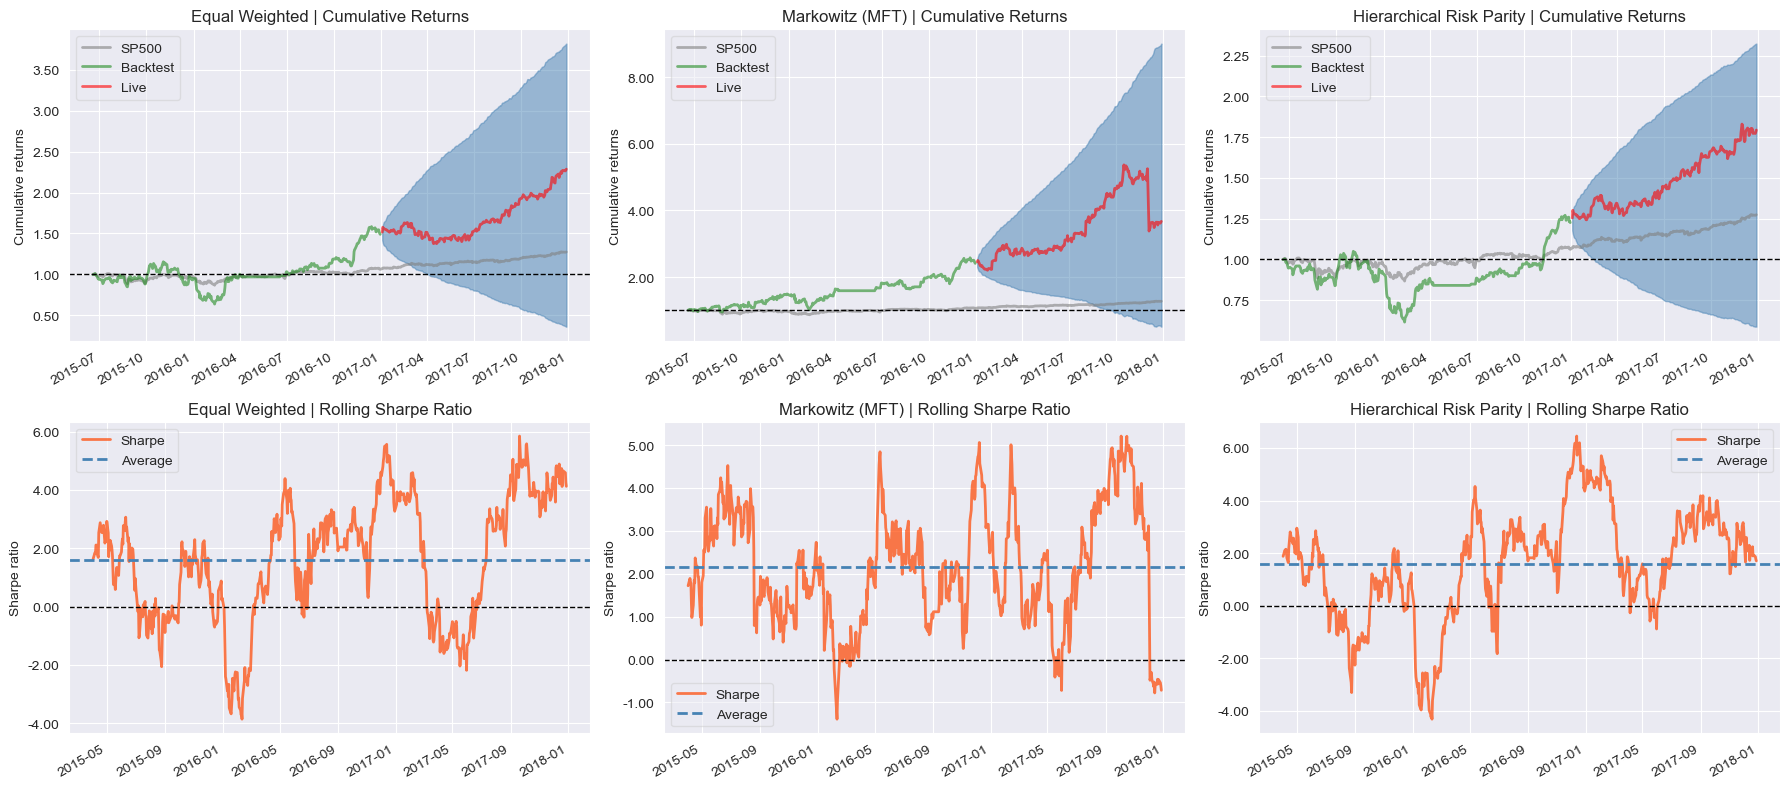

In [98]:
fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(18, 8))

for i, (algo, label) in enumerate(algo_labels.items()):
    returns = pd.read_hdf('backtests.h5', f'returns/{algo}')  
    returns2 = returns[returns.index >= '2015-06-19']  
    plot_rolling_returns(returns2,
                         factor_returns=benchmark,
                         live_start_date='2017-01-01',
                         logy=False,
                         cone_std=2,
                         legend_loc='best',
                         volatility_match=False,
                         cone_function=forecast_cone_bootstrap,
                        ax=axes[0][i])
    plot_rolling_sharpe(returns, ax=axes[1][i], rolling_window=63)
    axes[0][i].set_title(f'{label} | Cumulative Returns')
    axes[1][i].set_title(f'{label} | Rolling Sharpe Ratio')
    fig.tight_layout()

### Tear Sheets

In [99]:
def load_results(experiment='hrp'):
    with pd.HDFStore('backtests.h5') as store:
        returns = store.get('returns/{}'.format(experiment))
        positions = store.get('positions/{}'.format(experiment))
        transactions = store.get('transactions/{}'.format(experiment))
    return returns, positions, transactions

#### Equal Weighted

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,37.00,2017-10-16,2017-12-04,NaT,NaN
1,31.54,2015-12-29,2016-02-11,2016-03-29,66
2,16.38,2015-08-18,2015-08-24,2015-09-11,19
3,14.50,2016-12-20,2017-01-23,2017-02-09,38
4,13.79,2016-10-25,2016-11-10,2016-11-18,19


Stress Events,mean,min,max
Fall2015,0.17%,-11.81%,10.33%
New Normal,0.25%,-35.62%,11.88%


Top 10 long positions of all time,max
sid,
FOLD,110.09%
PNFP,105.77%
NVDA,103.14%
FIZZ,102.37%
TREE,102.25%
AIZ,102.06%
SGMS,101.61%
OZRK,101.09%
NUE,100.77%


Top 10 short positions of all time,max
sid,


Top 10 positions of all time,max
sid,
FOLD,110.09%
PNFP,105.77%
NVDA,103.14%
FIZZ,102.37%
TREE,102.25%
AIZ,102.06%
SGMS,101.61%
OZRK,101.09%
NUE,100.77%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$326457.03,$-59280.48,$385737.50
Gross profit,$2235541.66,$61286.31,$2174255.35
Gross loss,$-1909084.63,$-120566.79,$-1788517.85
Profit factor,$1.17,$0.51,$1.22
Avg. trade net profit,$160.97,$-1317.34,$194.52
Avg. winning trade,$2081.51,$3404.80,$2058.95
Avg. losing trade,$-2035.27,$-5023.62,$-1956.80
Ratio Avg. Win:Avg. Loss,$1.02,$0.68,$1.05
Largest winning trade,$72745.45,$19770.34,$72745.45
Largest losing trade,$-272215.42,$-18414.90,$-272215.42


Duration stats,All trades,Short trades,Long trades
Avg duration,5 days 01:32:39.763806706,100 days 05:10:39.933333333,2 days 21:43:19.699445284
Median duration,2 days 00:00:00,23 days 00:00:00,2 days 00:00:00
Longest duration,829 days 00:00:00,829 days 00:00:00,8 days 00:00:00
Shortest duration,0 days 03:00:01,0 days 20:59:59,0 days 03:00:01


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.06%,0.05%,0.06%
Avg returns winning,0.57%,1.84%,0.54%
Avg returns losing,-0.52%,-1.29%,-0.50%
Median returns all round_trips,0.01%,-0.04%,0.01%
Median returns winning,0.23%,0.99%,0.22%
Median returns losing,-0.20%,-1.12%,-0.20%
Largest winning trade,14.28%,12.12%,14.28%
Largest losing trade,-33.43%,-3.57%,-33.43%


Symbol stats,AAL,AAN,AAP,AAPL,ABMD,ACC,ACGL,ACIW,ADBE,ADM,ADP,ADSK,AEE,AEL,AET,AFG,AFSI,AGCO,AGN,AGO,AIG,AIT,AIV,AIZ,AKAM,ALB,ALE,ALGN,ALK,ALKS,ALNY,AMAT,AMD,AMED,AMGN,AMP,AMTD,AMZN,ANSS,ANTM,AON,AOS,ARNC,ARRY,ASGN,ATHN,ATI,ATVI,AVGO,AWI,AYI,AZPN,B,BA,BAH,BBY,BCO,BCPC,BDN,BDX,BECN,BG,BGCP,BID,BIDU,BIO,BKH,BLKB,BMRN,BMY,BOFI,BPOP,BR,BWA,BYD,CACC,CAG,CAKE,CASY,CAVM,CB,CBT,CBU,CCI,CCL,CCMP,CCOI,CE,CELG,CFX,CGNX,CHDN,CHE,CHFC,CHH,CHK,CHKP,CHTR,CI,CIM,CINF,CIT,CLF,CLR,CMA,CME,CMG,CMI,CMS,CNA,CNC,CNK,CNO,CNP,CNX,COHR,COL,COLB,COLM,COR,CPA,CREE,CRS,CSFL,CSGP,CSX,CTAS,CVBF,CVI,CVLT,CVS,CXW,CY,DAN,DAR,DDS,DE,DECK,DFS,DGX,DHI,DIS,DISH,DK,DLB,DLR,DLTR,DOV,DPS,DPZ,DRE,DRI,DTE,DXCM,DY,EA,EBAY,EBIX,EBS,ED,EE,EEFT,EGP,EIX,ELS,ENR,ENS,ENTG,ENV,EPR,EQIX,ERIE,ESGR,ESS,EVR,EXAS,EXEL,EXPO,FAF,FCNCA,FCX,FDX,FFBC,FFIV,FIBK,FICO,FISV,FIZZ,FLO,FNGN,FOLD,FSLR,FTNT,FULT,GD,GDOT,GEO,GGG,GGP,GLNG,GM,GNRC,GOLD,GPN,GPT,GRMN,GS,GTT,GVA,HAE,HAIN,HALO,HAS,HBI,HCSG,HEI,HELE,HFC,HIG,HLF,HOG,HOLX,HOMB,HPP,HPQ,HPT,HR,HRB,HRC,HRG,HRTX,HUM,HUN,IART,IBKR,IBM,ICUI,IDCC,IDTI,IDXX,IGT,IIVI,ILMN,IMMU,INCY,IPGP,IRM,IRWD,ISRG,ITRI,ITT,JACK,JBL,JBLU,JBT,JCI,JCOM,JEC,JKHY,JLL,JNJ,JNPR,KFY,KMPR,KMT,KMX,KR,KRC,KRO,KS,LANC,LFUS,LGND,LHCG,LII,LLY,LMT,LNC,LNG,LNT,LOGM,LOPE,LPX,LRCX,LUV,LVS,MAA,MANH,MAR,MASI,MDCO,MDP,MDR,MDSO,MDU,MGLN,MGM,MKC,MKL,MKSI,MKTX,MLM,MMM,MMS,MMSI,MNST,MOH,MRVL,MS,MSA,MSCI,MSM,MTG,MTZ,MU,MUR,MYGN,MYL,NAV,NBIX,NCR,NDAQ,NEE,NEM,NEOG,NFLX,NFX,NHI,NI,NJR,NKTR,NNI,NOV,NRG,NSC,NSP,NTAP,NTCT,NTRS,NUE,NUS,NUVA,NVDA,NYT,O,OAS,OC,OKE,OLED,OPK,ORA,ORCL,ORLY,OSK,OZRK,PCG,PCH,PDCE,PEGA,PENN,PG,PHM,PII,PLD,PLT,PM,PNFP,PNM,PODD,POOL,POR,PPC,PPL,PRU,PTEN,PVH,PWR,PXD,QDEL,QGEN,RBC,RCL,RDN,RE,REGN,RES,RGLD,RIG,RNR,ROLL,ROP,RP,RRC,RSG,S,SBGI,SCCO,SEB,SEIC,SEM,SFLY,SFNC,SGEN,SGMS,SIGI,SIVB,SIX,SJI,SJM,SKX,SKYW,SLAB,SLGN,SM,SMG,SMTC,SNV,SON,SPR,SSD,STL,STLD,STMP,STZ,SUI,SWKS,SWN,SWX,SYMC,TAL,TAP,TCBI,TDG,TECD,TECH,TER,THG,THO,TMUS,TREE,TREX,TRGP,TRN,TROX,TSLA,TSN,TSS,TTC,TTEK,TTWO,TXRH,TYL,UAA,UAL,UBSH,UCBI,UDR,UGI,ULTA,UNF,URBN,URI,USB,USNA,UTHR,V,VG,VMC,VMW,VR,VRSK,VRSN,VRTX,VRX,VSH,VTR,VVC,WAFD,WAL,WAT,WCG,WDC,WEN,WERN,WLK,WMB,WMGI,WOR,WRB,WSO,WST,WTFC,WU,WWE,WWW,WYNN,X,XEL,XL,XPO,XRAY,Y,YUM,ZBRA
Avg returns all round_trips,0.08%,-0.62%,-0.10%,0.12%,0.49%,0.10%,-0.14%,-0.46%,0.16%,0.19%,0.05%,-0.13%,0.00%,-0.10%,-1.07%,0.63%,-0.15%,NaN,-0.14%,-0.18%,-0.60%,1.27%,0.07%,-0.29%,-0.02%,0.36%,0.03%,0.36%,0.87%,0.00%,-0.02%,-0.36%,0.61%,0.26%,0.60%,0.68%,-0.02%,0.37%,0.13%,0.10%,0.26%,-2.01%,0.01%,-0.08%,-0.19%,-0.03%,0.25%,0.61%,-0.11%,0.41%,-0.32%,1.20%,-0.20%,0.08%,-0.02%,0.00%,0.16%,0.13%,-0.07%,0.39%,-0.02%,0.09%,0.17%,0.12%,0.22%,-0.02%,0.37%,0.99%,0.00%,0.02%,-1.12%,-0.32%,-0.34%,0.08%,-0.22%,0.12%,-1.06%,0.00%,-0.22%,-0.10%,-0.18%,-0.04%,-0.07%,-0.71%,-0.03%,-0.16%,-0.33%,NaN,-3.98%,-0.04%,-33.43%,2.81%,-0.06%,0.11%,0.08%,-0.01%,0.04%,0.05%,0.66%,0.16%,-0.32%,-0.76%,-0.10%,-0.00%,0.44%,0.24%,0.00%,0.48%,0.03%,0.25%,-0.30%,0.18%,-0.41%,-0.53%,-0.06%,0.06%,0.80%,-0.13%,0.39%,0.45%,-0.04%,0.16%,1.03%,0.62%,0.07%,-0.24%,-0.08%,-0.11%,0.05%,-0.06%,1.02%,0.03%,0.50%,0.04%,0.19%,0.02%,0.71%,0.19%,-0.17%,0.05%,0.02%,0.06%,0.35%,0.47%,1.55%,0.06%,-0.22%,0.06%,-0.03%,0.13%,-0.23%,1.71%,0.08%,0.29%,-0.47%,0.48%,0.02%,-0.18%,1.54%,0.00%,0.12%,0.22%,-0.02%,0.10%,2.10%,-0.18%,0.17%,-0.02%,-0.09%,0.20%,0.12%,-0.03%,0.01%,0.15%,0.42%,-0.25%,0.35%,0.02%,-0.39%,-0.01%,-0.05%,-0.01%,0.26%,0.21%,-0.11%,-0.73%,0.01%,0.50%,0.01%,0.05%,0.04%,-0.04%,-0.24%,0.32%,-0.22%,0.52%,-0.24%,-0.36%,-0.02%,-0.03%,-0.16%,0.00%,-0.53%,-1.01%,0.22%,0.06%,0.21%,-0.00%,-1.77%,0.26%,0.05%,0.44%,0.11%,0.36%,0.83%,-0.42%,-0.21%,-0.34%,-0.48%,-0.10%,0.12%,0.86%,-1.27%,0.19%,0.30%,-0.14%,0.27%,0.10%,0.13%,0.06%,-0.05%,0.29%,NaN,0.12%,5.89%,-0.02%,0.16%,0.83%,-0.60%,0.21%,0.23%,0.14%,0.51%,0.20%,-0.46%,0.23%,-0.11%,-0.04%,-1.74%,-0.86%,0.03%,0.34%,0.26%,0.07%,-0.41%,NaN,-1.35%,-0.25%,-0.03%,NaN,0.05%,-0.07%,-0.07%,0.19%,0.07%,-0.96%,-1.52%,0.06%,0.43%,0.12%,0.33%,0.34%,0.28%,-0.10%,-1.21%,-2.16%,0.10%,0.04%,-0.02%,

Profitability (PnL / PnL total) per name,
symbol,
AMD,27.04%
STMP,25.44%
EXEL,20.07%
IMMU,16.64%
TROX,13.55%
TREE,13.18%
KRO,11.70%
FIZZ,8.48%
NKTR,7.44%


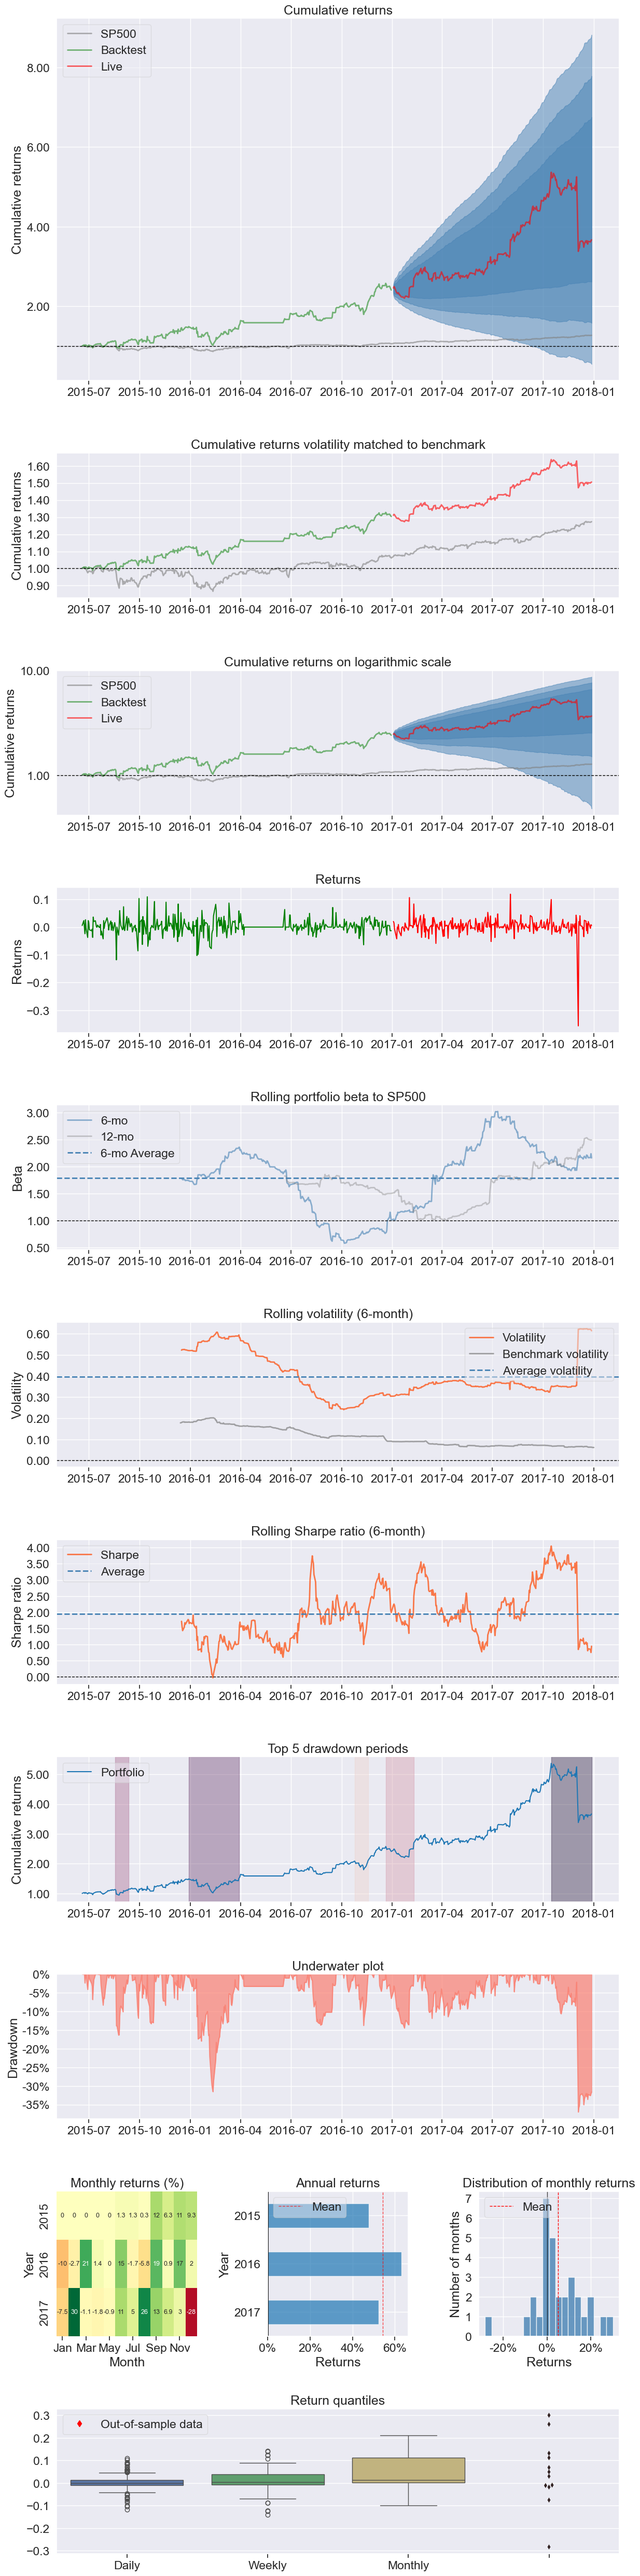

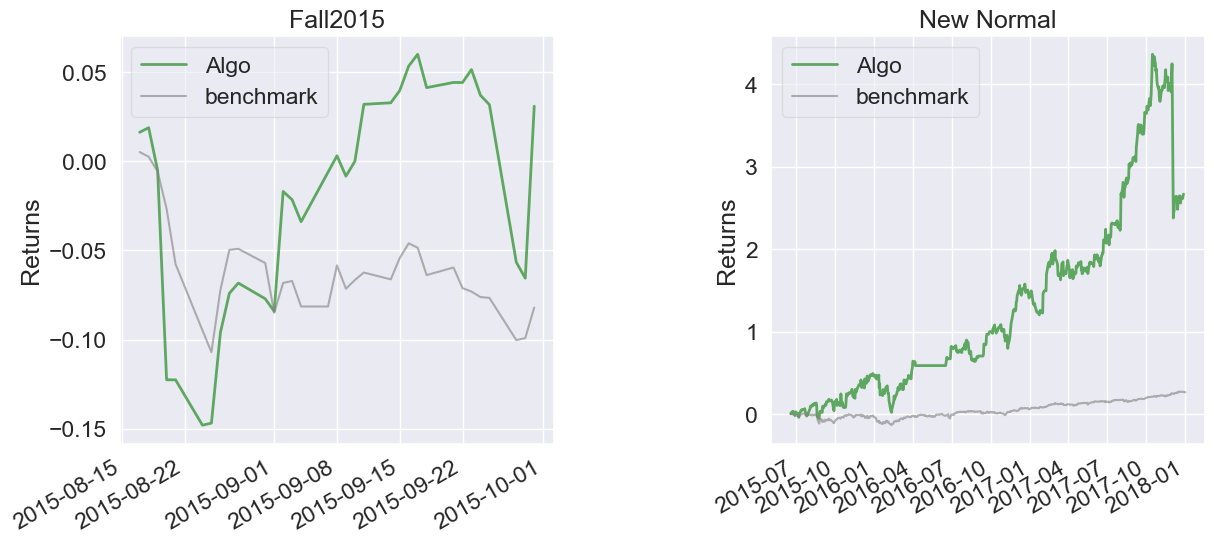

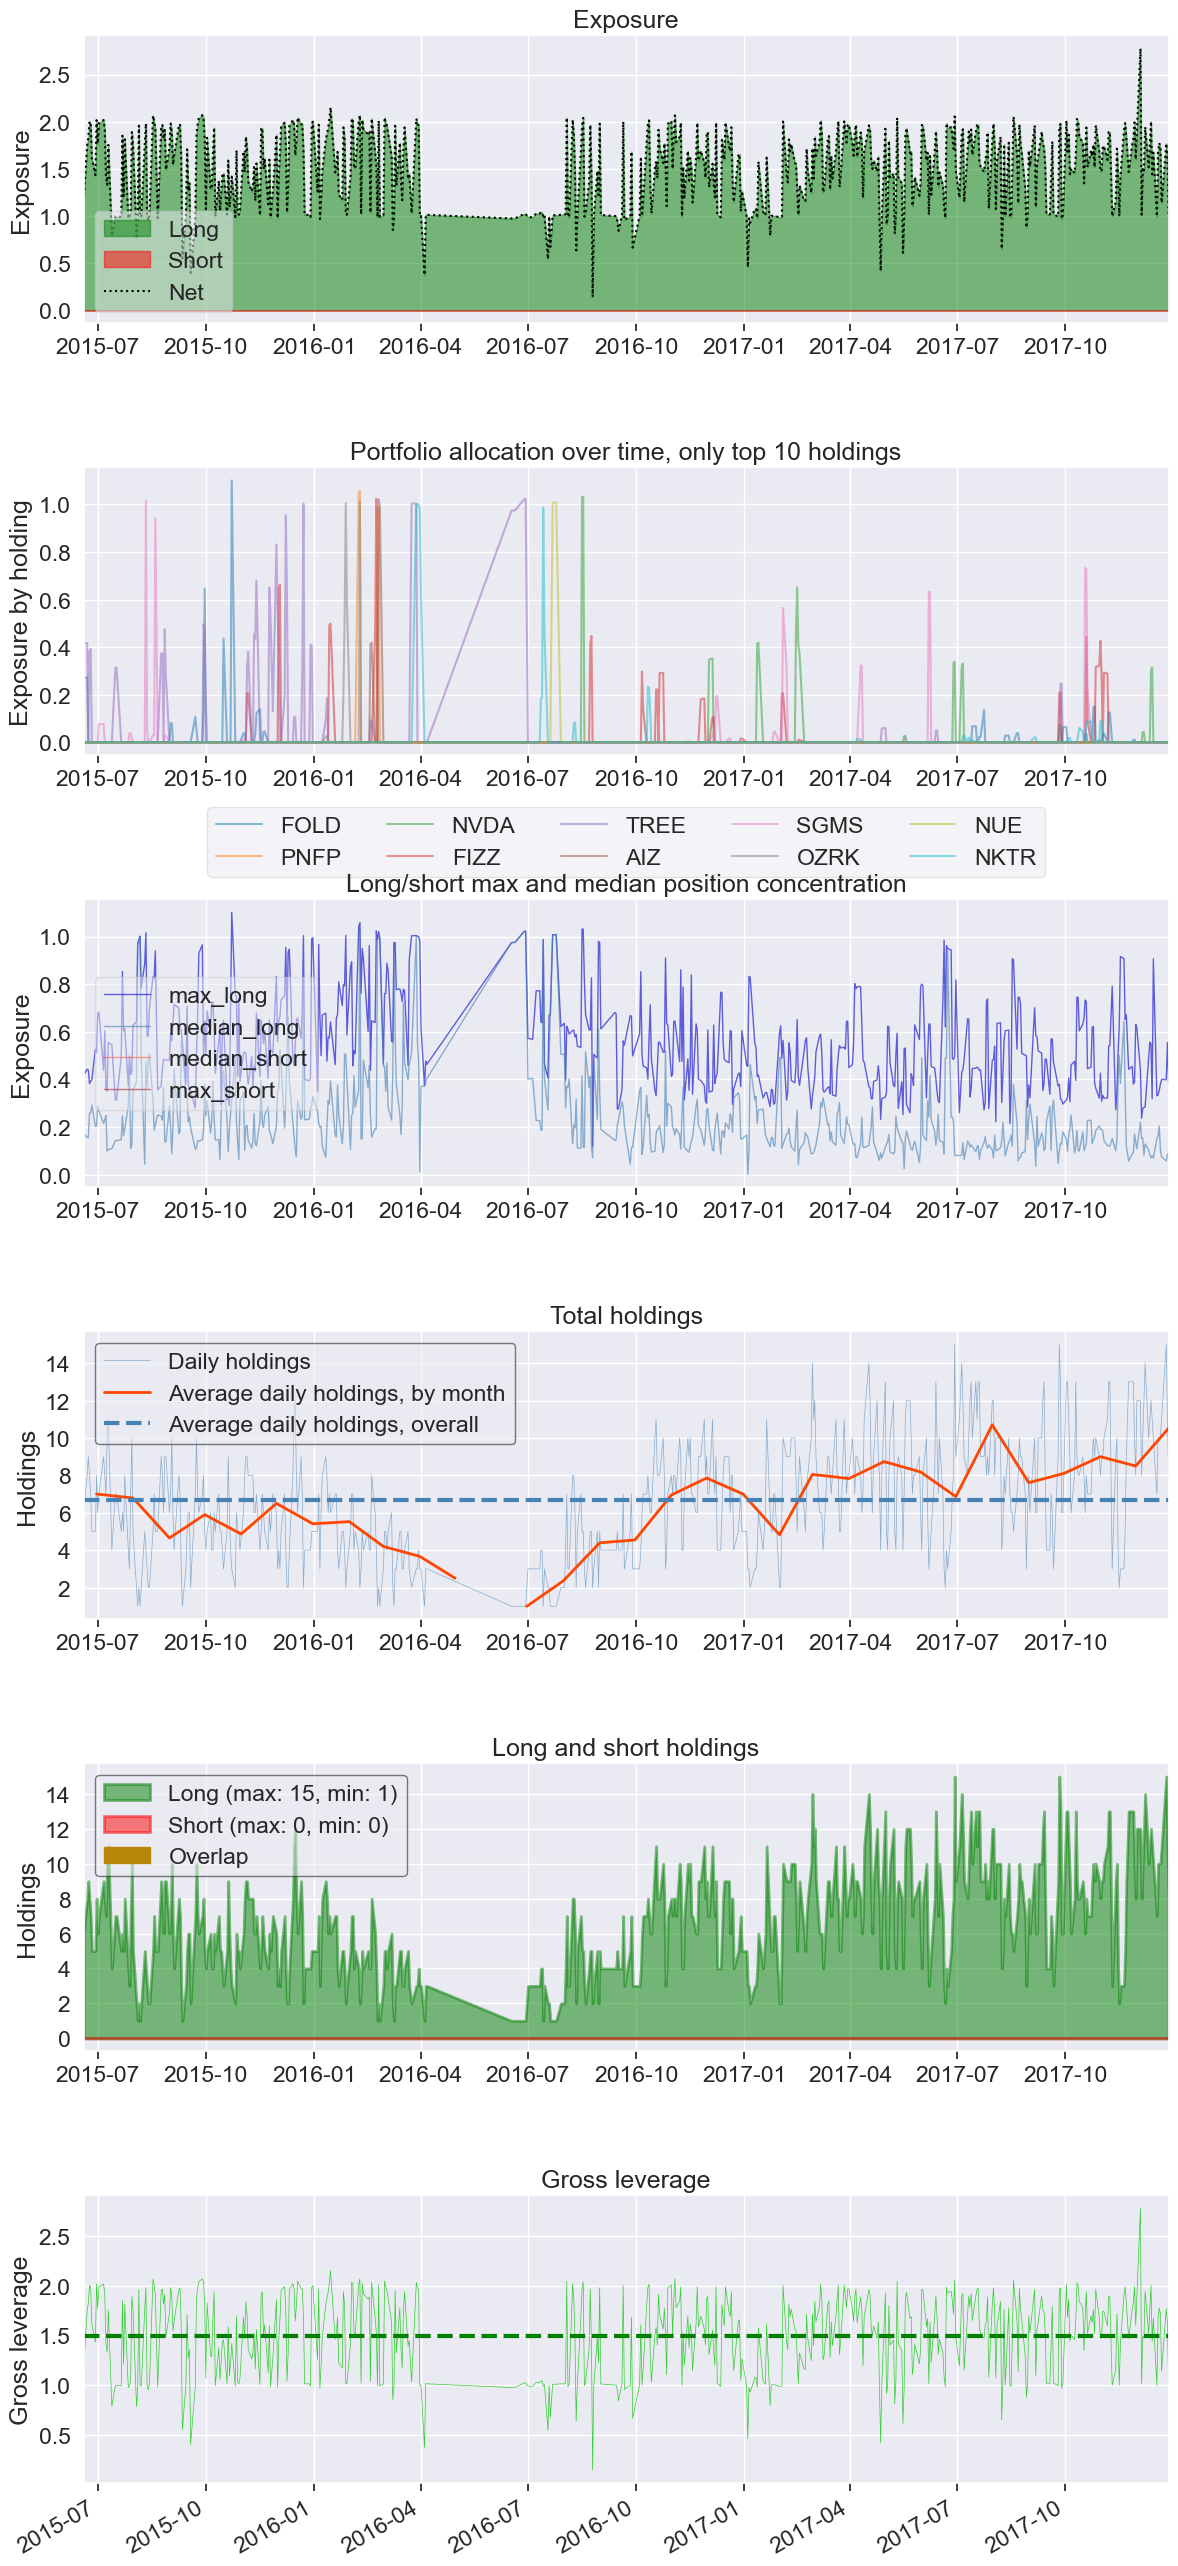

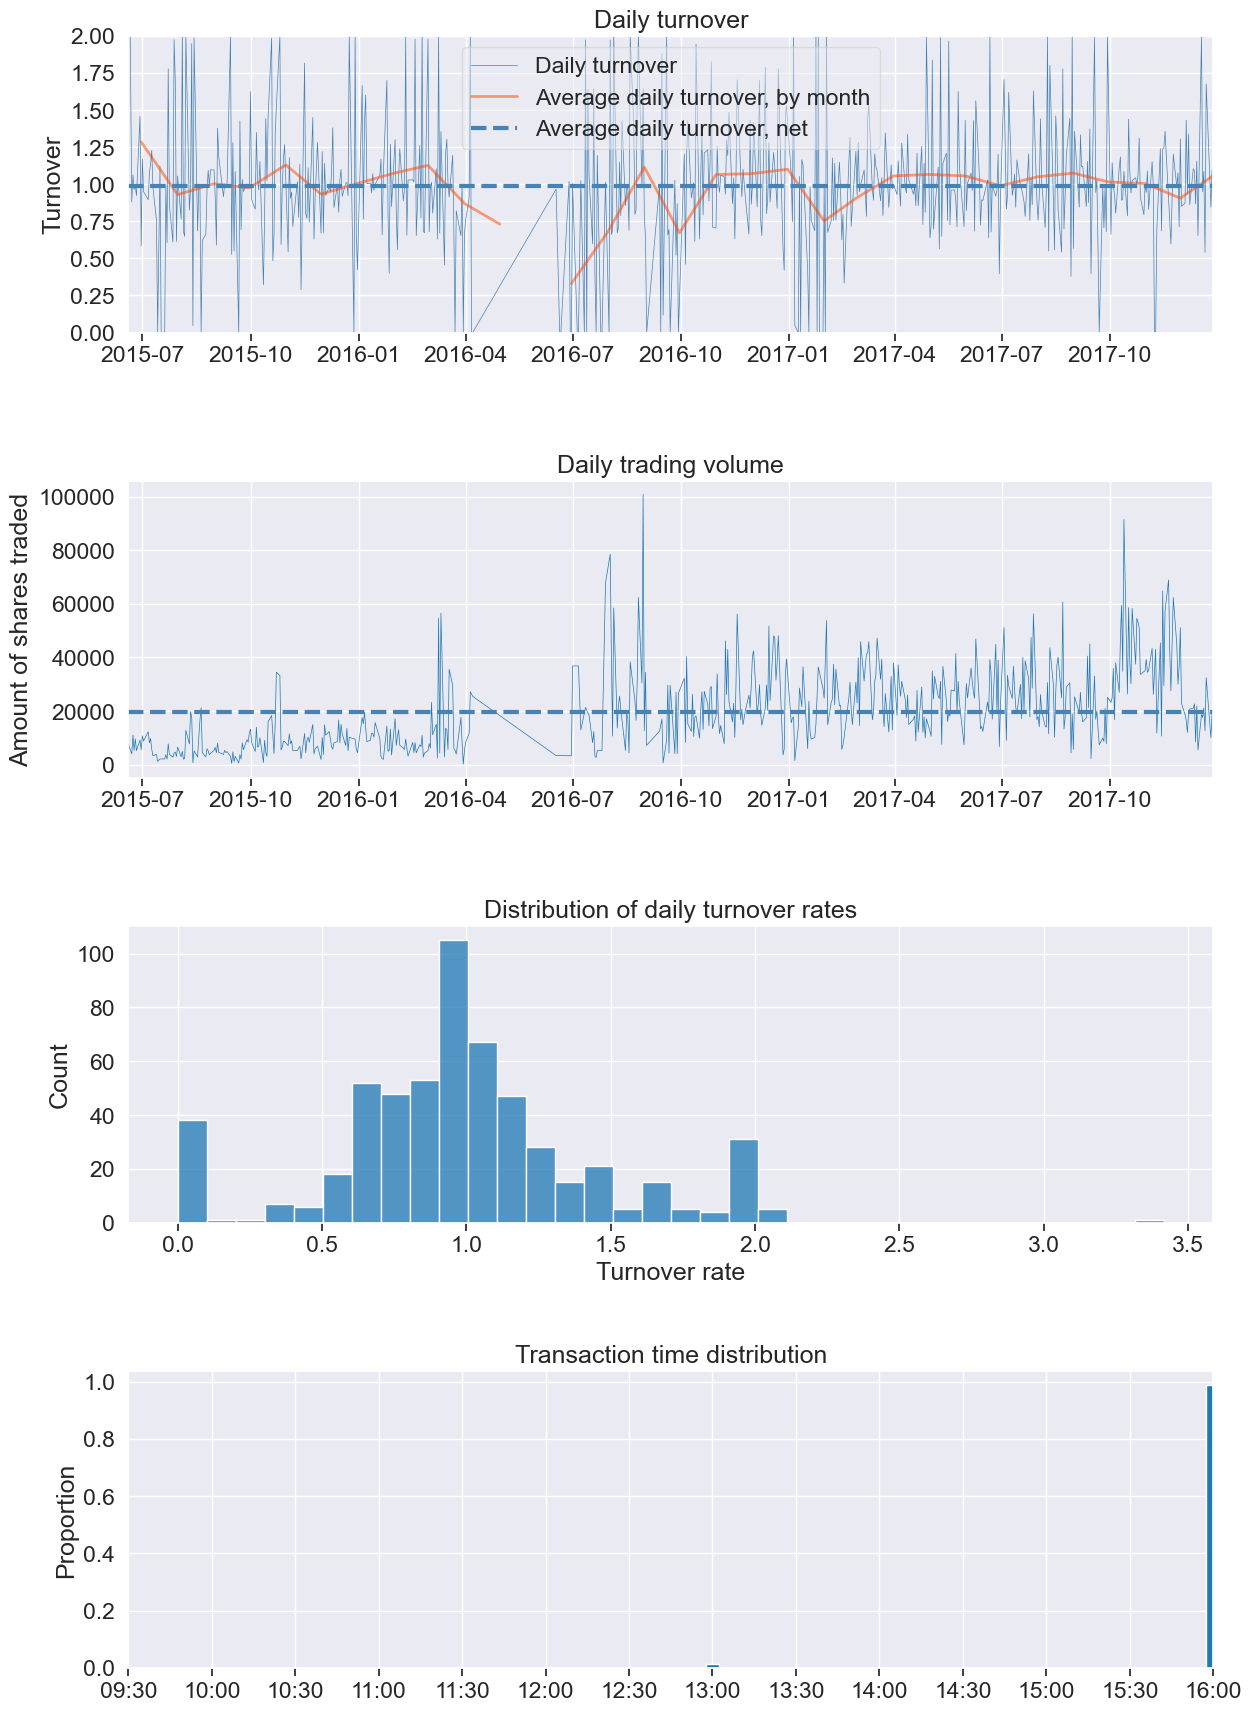

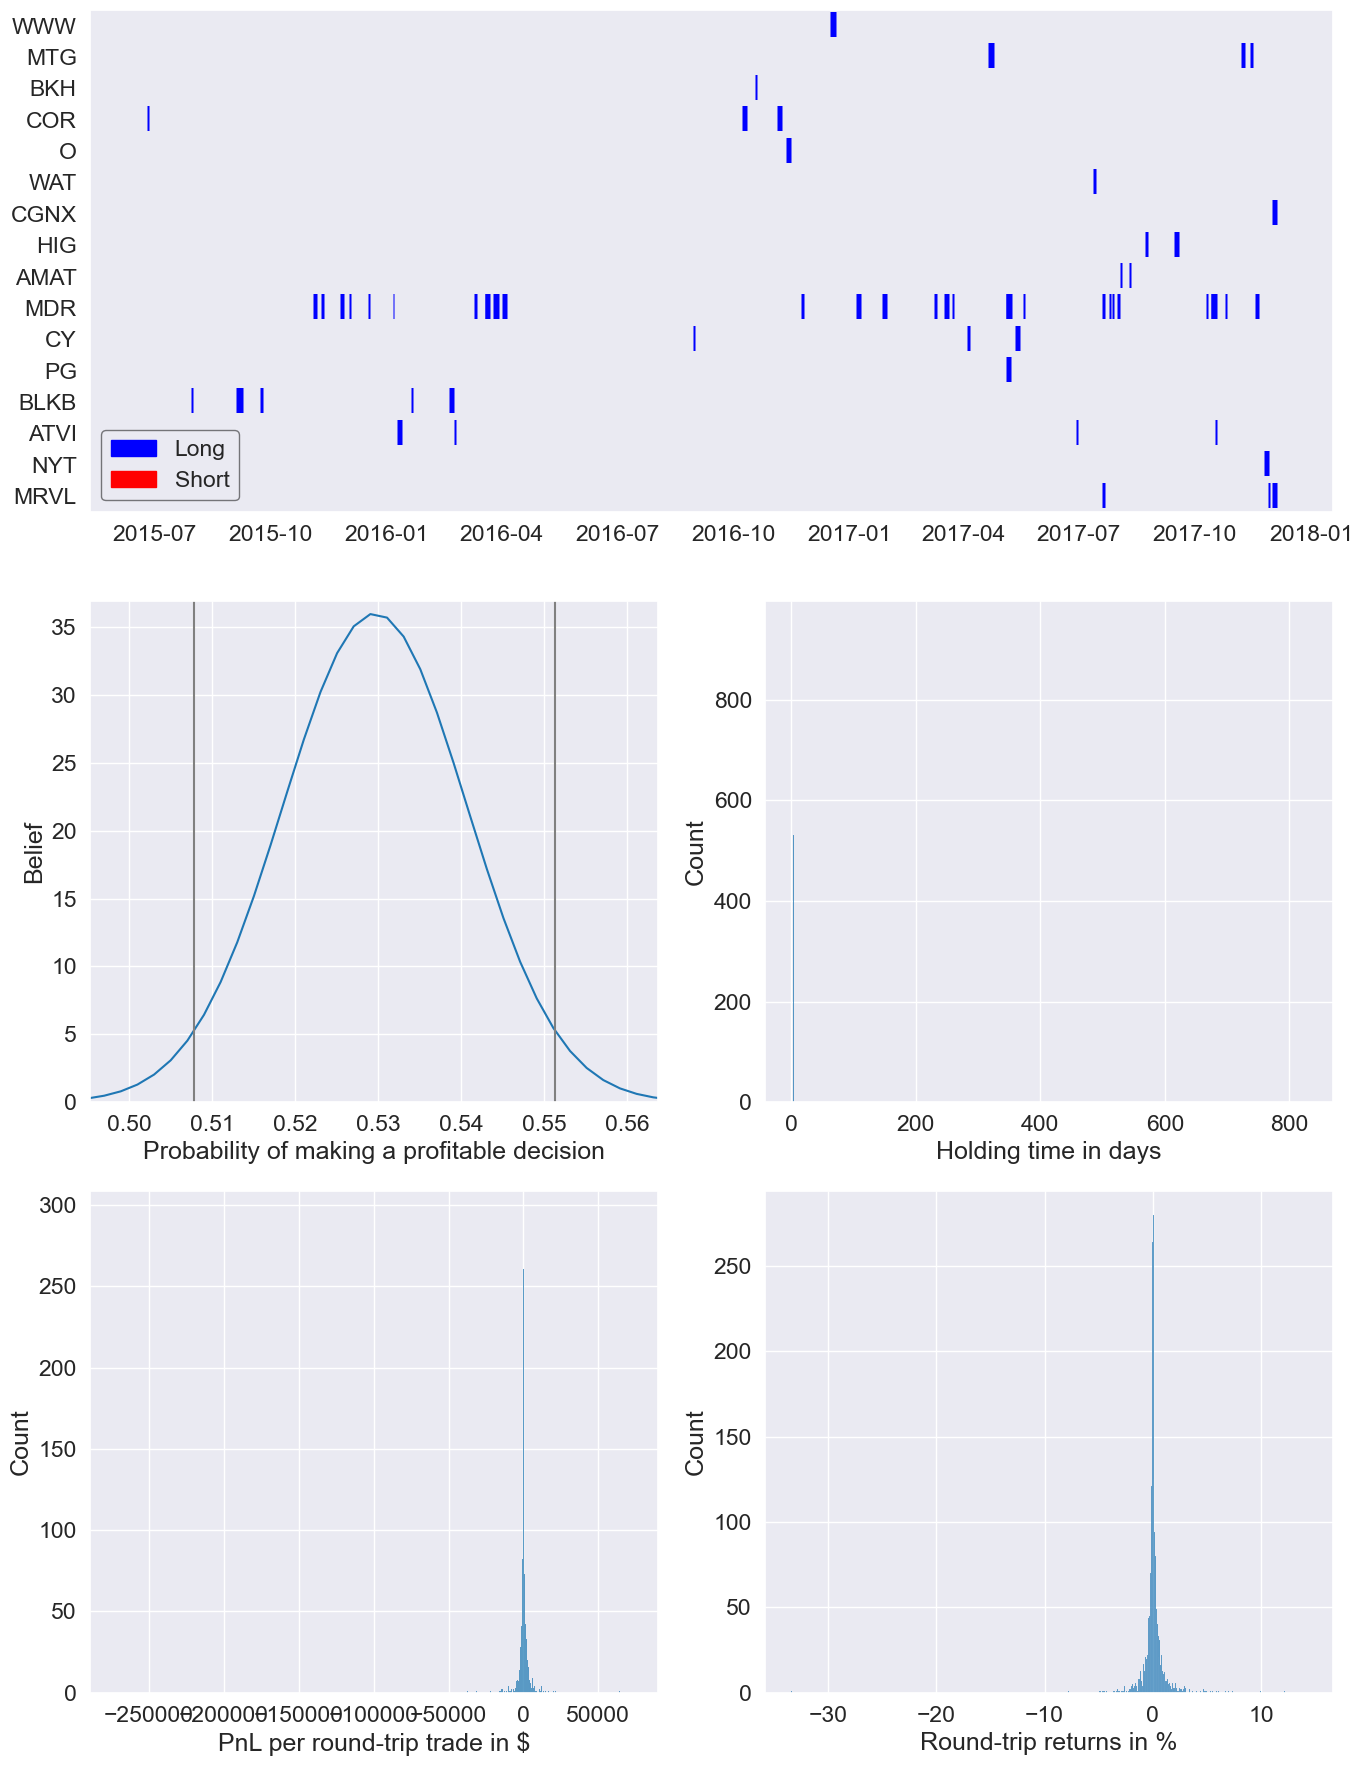

In [101]:
experiment = 'markowitz'
returns, positions, transactions = load_results(experiment)
returns2 = returns[returns.index >= '2015-06-19']
positions2 = positions[positions.index >= '2015-06-19']
transactions2 = transactions[transactions.index >= '2015-06-19']
pf.create_full_tear_sheet(returns2, 
                          positions=positions2, 
                          transactions=transactions2,
                          benchmark_rets=benchmark,
                          live_start_date='2017-01-01', 
                          round_trips=True)

#### HRP

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,35.43,2015-06-23,2016-01-20,2016-11-15,366
1,9.89,2017-03-01,2017-03-21,2017-07-14,98
2,8.42,2015-02-18,2015-03-10,2015-04-08,36
3,6.78,2017-09-01,2017-09-07,2017-10-16,32
4,6.75,2015-01-08,2015-01-15,2015-01-27,14


Stress Events,mean,min,max
Fall2015,-0.31%,-5.66%,5.64%
New Normal,0.09%,-7.25%,6.98%


Top 10 long positions of all time,max
sid,
DHR,52.47%
RNR,41.26%
STWD,39.77%
ACGL,34.90%
CLX,33.05%
AIV,32.47%
ANAT,32.11%
MAA,31.25%
TWO,30.55%


Top 10 short positions of all time,max
sid,


Top 10 positions of all time,max
sid,
DHR,52.47%
RNR,41.26%
STWD,39.77%
ACGL,34.90%
CLX,33.05%
AIV,32.47%
ANAT,32.11%
MAA,31.25%
TWO,30.55%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$96210.88,$-1405.02,$97615.90
Gross profit,$700392.70,$2047.17,$698345.52
Gross loss,$-604181.82,$-3452.19,$-600729.63
Profit factor,$1.16,$0.59,$1.16
Avg. trade net profit,$7.58,$-31.93,$7.71
Avg. winning trade,$106.52,$70.59,$106.68
Avg. losing trade,$-99.96,$-230.15,$-99.64
Ratio Avg. Win:Avg. Loss,$1.07,$0.31,$1.07
Largest winning trade,$2978.25,$247.04,$2978.25
Largest losing trade,$-4817.28,$-825.93,$-4817.28


Duration stats,All trades,Short trades,Long trades
Avg duration,3 days 09:59:49.231005,27 days 11:28:38.181818,3 days 07:59:22.172947
Median duration,2 days 00:00:00,9 days 00:00:00,2 days 00:00:00
Longest duration,246 days 04:00:01,221 days 01:00:00,246 days 04:00:01
Shortest duration,0 days 03:00:01,1 days 00:00:00,0 days 03:00:01


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.01%,-0.02%,0.01%
Avg returns winning,0.09%,0.06%,0.09%
Avg returns losing,-0.09%,-0.17%,-0.09%
Median returns all round_trips,0.00%,0.01%,0.00%
Median returns winning,0.05%,0.04%,0.05%
Median returns losing,-0.05%,-0.15%,-0.05%
Largest winning trade,3.02%,0.21%,3.02%
Largest losing trade,-4.38%,-0.68%,-4.38%


Symbol stats,A,AAL,AAN,AAP,AAPL,ABC,ABMD,ABT,ACC,ACGL,ACIW,ACM,ACN,ACXM,ADBE,ADI,ADM,ADP,ADS,ADSK,AEE,AEL,AEO,AEP,AET,AFG,AFSI,AGCO,AGN,AGNC,AGO,AHL,AIG,AIV,AIZ,AJG,AKAM,ALB,ALE,ALGN,ALK,ALKS,ALL,ALNY,ALXN,AMAT,AMD,AME,AMED,AMG,AMGN,AMP,AMT,AMTD,AMZN,AN,ANAT,ANSS,ANTM,AON,AOS,APA,APC,APD,ARE,ARNC,ARRS,ARRY,ARW,ASGN,ASH,ATHN,ATI,ATO,ATR,ATVI,AVGO,AVT,AVX,AVY,AWI,AWK,AXP,AXS,AYI,AZO,AZPN,B,BA,BAC,BAH,BAX,BBBY,BBT,BBY,BC,BCO,BCPC,BDC,BDN,BDX,BECN,BEN,BG,BGCP,BID,BIDU,BIIB,BIO,BK,BKH,BLK,BLKB,BLL,BMRN,BMS,BMY,BOFI,BOH,BOKF,BP,BPOP,BR,BRKR,BRO,BSX,BWA,BXP,BXS,BYD,C,CA,CACC,CACI,CAG,CAH,CAKE,CAR,CASY,CAT,CATY,CAVM,CB,CBOE,CBRL,CBSH,CBT,CBU,CCE,CCK,CCL,CCMP,CCOI,CDNS,CE,CELG,CERN,CF,CFR,CFX,CGNX,CHD,CHDN,CHE,CHFC,CHH,CHK,CHKP,CHRW,CHTR,CI,CIEN,CIM,CINF,CIT,CL,CLF,CLGX,CLH,CLNY,CLR,CLX,CMA,CMC,CMCSA,CMG,CMI,CMS,CNA,CNC,CNK,CNO,CNP,CNX,COF,COG,COHR,COLB,COLM,COO,COP,COR,COST,CPA,CPB,CPRT,CPT,CR,CREE,CRI,CRL,CRM,CRS,CSFL,CSGP,CSX,CTAS,CTL,CTSH,CTXS,CUBE,CUZ,CVBF,CVI,CVLT,CVS,CVX,CW,CXO,CXW,CY,D,DAL,DAN,DAR,DCI,DCT,DDS,DE,DECK,DEI,DFS,DG,DGX,DHI,DHR,DISCA,DISCK,DISH,DK,DKS,DLB,DLR,DLTR,DLX,DNB,DO,DOV,DOX,DPS,DPZ,DRE,DRH,DRI,DTE,DUK,DVA,DVN,DXCM,DY,EA,EBAY,EBIX,EBS,ED,EDR,EE,EEFT,EFX,EGN,EGP,EIX,EL,ELS,EME,EMN,EMR,ENR,ENS,ENTG,ENV,EOG,EPR,EQIX,EQR,EQT,ERIE,ESGR,ESRX,ESS,ESV,ETFC,ETN,ETR,EV,EVR,EW,EWBC,EXAS,EXC,EXEL,EXP,EXPD,EXPE,EXPO,EXR,F,FAF,FAST,FCFS,FCNCA,FCX,FDS,FDX,FE,FFBC,FFIN,FFIV,FHN,FIBK,FICO,FIS,FISV,FITB,FIZZ,FL,FLIR,FLO,FLR,FLS,FLT,FMBI,FMC,FNB,FNF,FNGN,FOLD,FOX,FOXA,FR,FRT,FSLR,FTI,FTNT,FUL,FULT,G,GBCI,GD,GDOT,GE,GEO,GGP,GHC,GILD,GIS,GLNG,GM,GNRC,GNTX,GOLD,GOOGL,GPC,GPK,GPN,GPS,GPT,GRMN,GS,GT,GTT,GVA,GWR,GWW,H,HAE,HAIN,HAL,HALO,HAS,HBAN,HBI,HCP,HCSG,HD,HE,HEI,HELE,HES,HFC,HHC,HI,HIG,HIW,HLF,HOG,HOLX,HOMB,HON,HP,HPP,HPQ,HR,HRB,HRC,HRG,HRL,HRS,HRTX,HSIC,HST,HSY,HUM,HUN,HXL,IART,IBKC,IBKR,IBM,IBOC,ICE,ICUI,IDA,IDCC,IDTI,IDXX,IGT,IIVI,ILMN,IMMU,INCY,INGR,INTC,INTU,IPG,IPGP,IR,IRM,IRWD,ISBC,ISRG,ITRI,ITT,ITW,IVZ,JACK,JBHT,JBL,JBLU,JBT,JCI,JCOM,JEC,JJSF,JKHY,JLL,JNJ,JNPR,JPM,JWN,K,KAR,KBR,KEX,KEY,KFY,KIM,KLAC,KMB,KMPR,KMT,KMX,KNX,KO,KR,KRC,KRO,KS,KSS,KSU,KW,L,LAMR,LANC,LAZ,LB,LBTYA,LDOS,LEA,LECO,LEG,LEN,LFUS,LGND,LHCG,LHO,LII,LKQ,LLL,LLY,LM,LMT,LNC,LNG,LNT,LOGM,LOPE,LOW,LPLA,LPX,LRCX,LSI,LSTR,LUV,LVS,LYB,LYV,M,MA,MAA,MAC,MAN,MANH,MAR,MAS,MASI,MAT,MBFI,MCD,MCHP,MCK,MCO,MCY,MD,MDCO,MDLZ,MDP,MDR,MDSO,MDT,MDU,MET,MFA,MGLN,MGM,MIDD,MKC,MKL,MKSI,MKTX,MLM,MMM,MMS,MMSI,MNST,MO,MOH,MORN,MOS,MPW,MPWR,MRO,MRVL,MS,MSA,MSCI,MSG,MSI,MSM,MTD,MTG,MTN,MTX,MTZ,MU,MUR,MXIM,MYGN,MYL,NATI,NAV,NBIX,NBL,NCR,NDAQ,NDSN,NEE,NEM,NEOG,NEU,NFG,NFLX,NFX,NHI,NI,NJR,NKE,NKTR,NLY,NNI,NOC,NOV,NRG,NSC,NSP,NTAP,NTCT,NTRS,NUAN,NUE,NUS,NUVA,NVDA,NVR,NWE,NWL,NXST,NYCB,NYT,O,OAS,OC,ODFL,OFC,OGE,OHI,OI,OII,OKE,OLED,OLN,OMC,ONB,OPK,ORA,ORCL,ORLY,OSK,OXY,OZRK,PACW,PAG,PAY,PAYX,PB,PBCT,PCAR,PCG,PCH,PDCE,PDM,PEB,PEG,PEGA,PENN,PEP,PFE,PFG,PG,PGR,PH,PHM,PII,PKG,PKI,PLD,PLT,PM,PNC,PNFP,PNM,PNR,PNW,PODD,POL,POOL,POR,PPC,PPL,PRGO,PRI,PRU,PSA,PSB,PSMT,PTEN,PVH,PWR,PX,PXD,QCOM,QDEL,R,RBC,RCL,RDN,RE,REG,REGN,RES,RF,RGA,RGLD,RHI,RHP,RHT,RIG,RJF,RL,RLI,RMD,RNR,ROL,ROLL,ROP,ROST,RP,RPM,RRC,RS,RTN,RYN,S,SAM,SATS,SBAC,SBGI,SBNY,SBRA,SBUX,SCCO,SCG,SCHW,SCI,SE,SEB,SEE,SEIC,SEM,SF,SFLY,SFNC,SGEN,SGMS,SHO,SHOO,SHW,SIG,SIGI,SIRI,SIVB,SIX,SJI,SJM,SKX,SKYW,SLAB,SLB,SLG,SLGN,SLM,SM,SMG,SMTC,SNA,SNH,SNV,SNX,SON,SPG,SPR,SRCL,SRE,SSD,SSNC,STE,STI,STL,STLD,STMP,STT,STWD,STX,STZ,SUI,SWK,SWKS,SWN,SWX,SXT,SYK,SYMC,SYNT,SYY,T,TAL,TAP,TCBI,TCO,TDC,TDG,TDS,TDY,TECD,TECH,TEL,TER,TEX,TFSL,TFX,TGT,THC,THG,THO,THS,TIF,TKR,TMK,TMO,TMUS,TOL,TPX,TREE,TREX,TRGP,TRI,TRMB,TRN,TROW,TROX,TRV,TSCO,TSLA,TSN,TSS,TTC,TTEK,TTWO,TWO,TXN,TXRH,TXT,TYL,UAA,UAL,UBSH,UBSI,UCBI,UDR,UFS,UGI,UHAL,UHS,ULTA,ULTI,UMBF,UMPQ,UNF,UNH,UNM,UNP,UPS,URBN,URI,USB,USG,USM,USNA,UTHR,UTX,V,VAR,VC,VFC,VG,VGR,VIAB,VLO,VLY,VMC,VMI,VMW,VNO,VOD,VR,VRNT,VRSK,VRSN,VRTX,VRX,VSAT,VSH,VTR,VVC,VZ,WAB,WAFD,WAL,WBA,WBC,WBS,WCC,WCG,WCN,WDC,WEC,WEN,WERN,WEX,WFC,WGL,WHR,WLK,WLL,WM,WMB,WMGI,WMT,WOR,WRB,WRI,WSM,WSO,WST,WTFC,WTM,WTR,WTS,WU,WWD,WWE,WWW,WY,WYNN,X,X

Profitability (PnL / PnL total) per name,
symbol,
NEM,4.28%
FIZZ,2.90%
LHCG,2.79%
IMMU,2.62%
TEX,2.47%
STX,2.43%
AET,2.39%
PODD,2.20%
OLED,2.14%


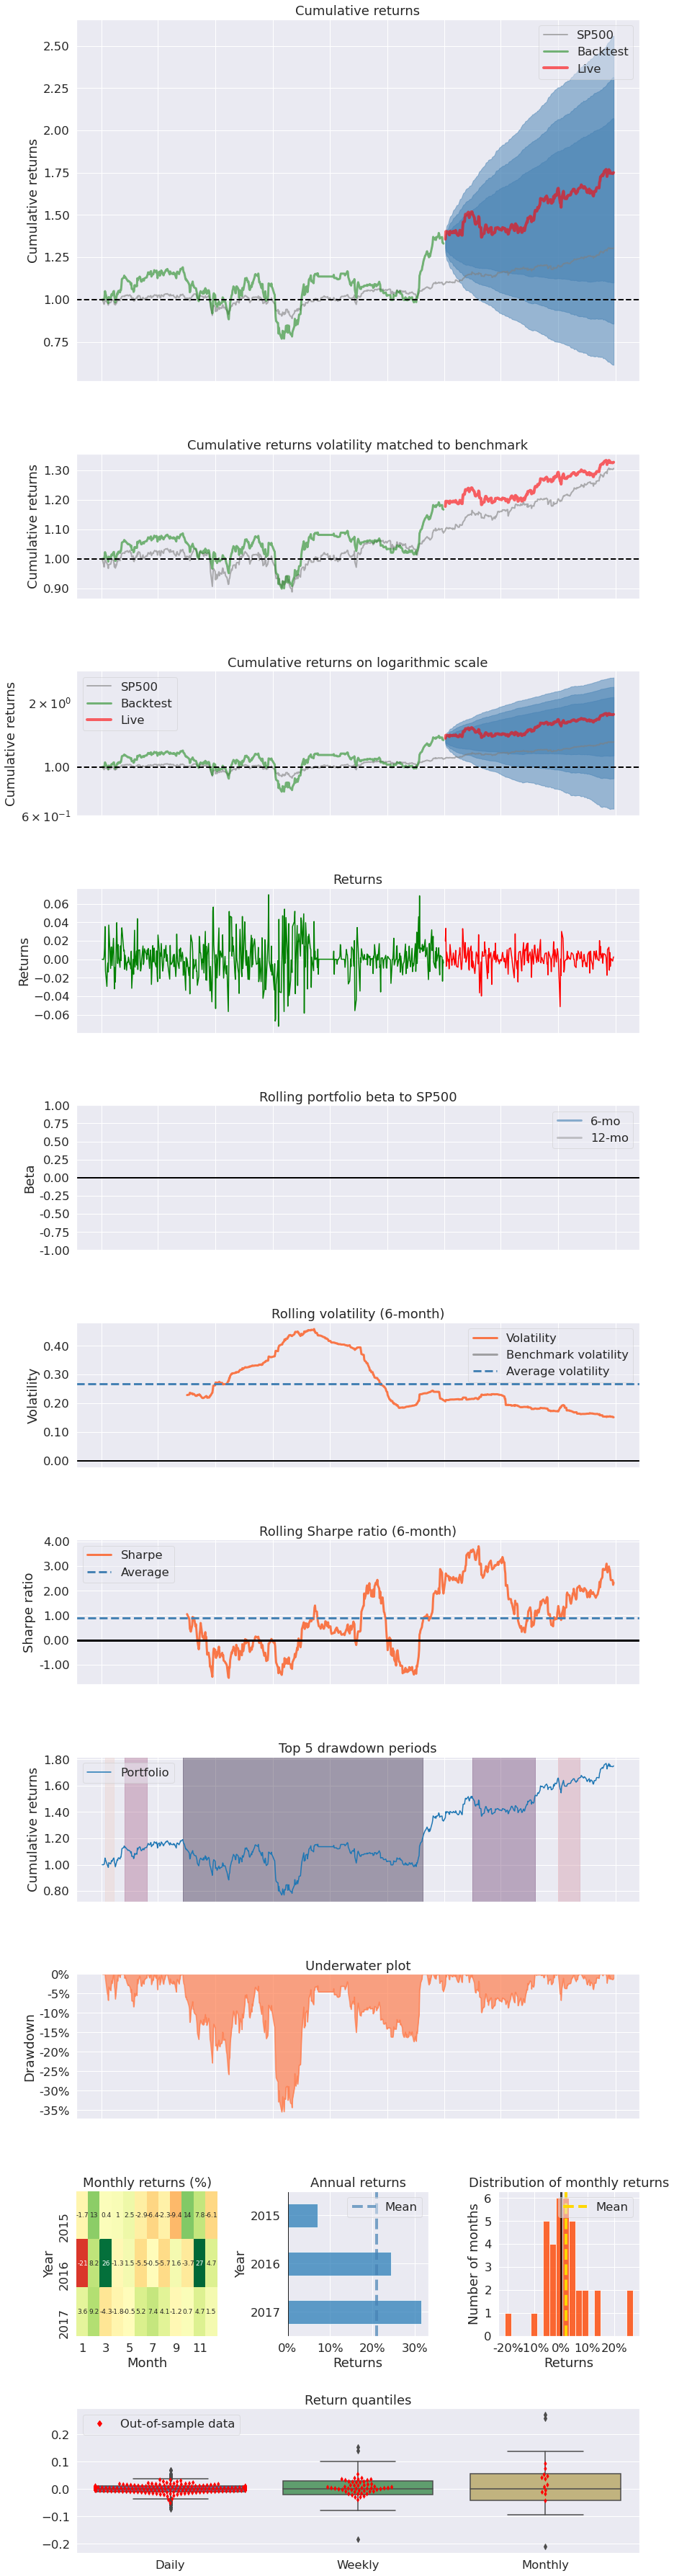

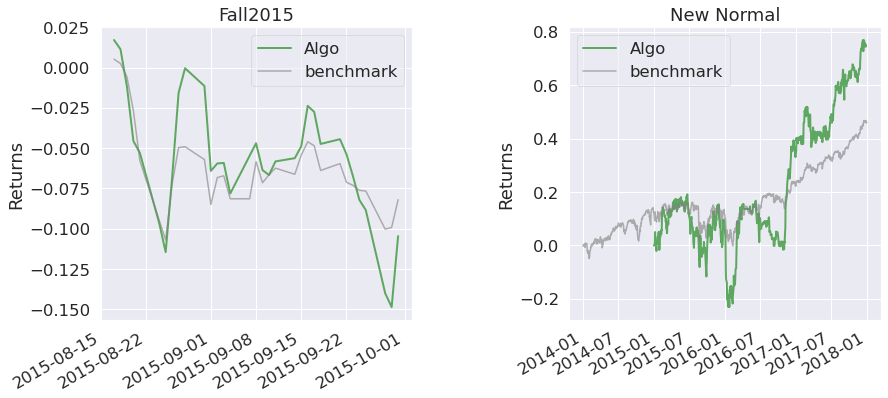

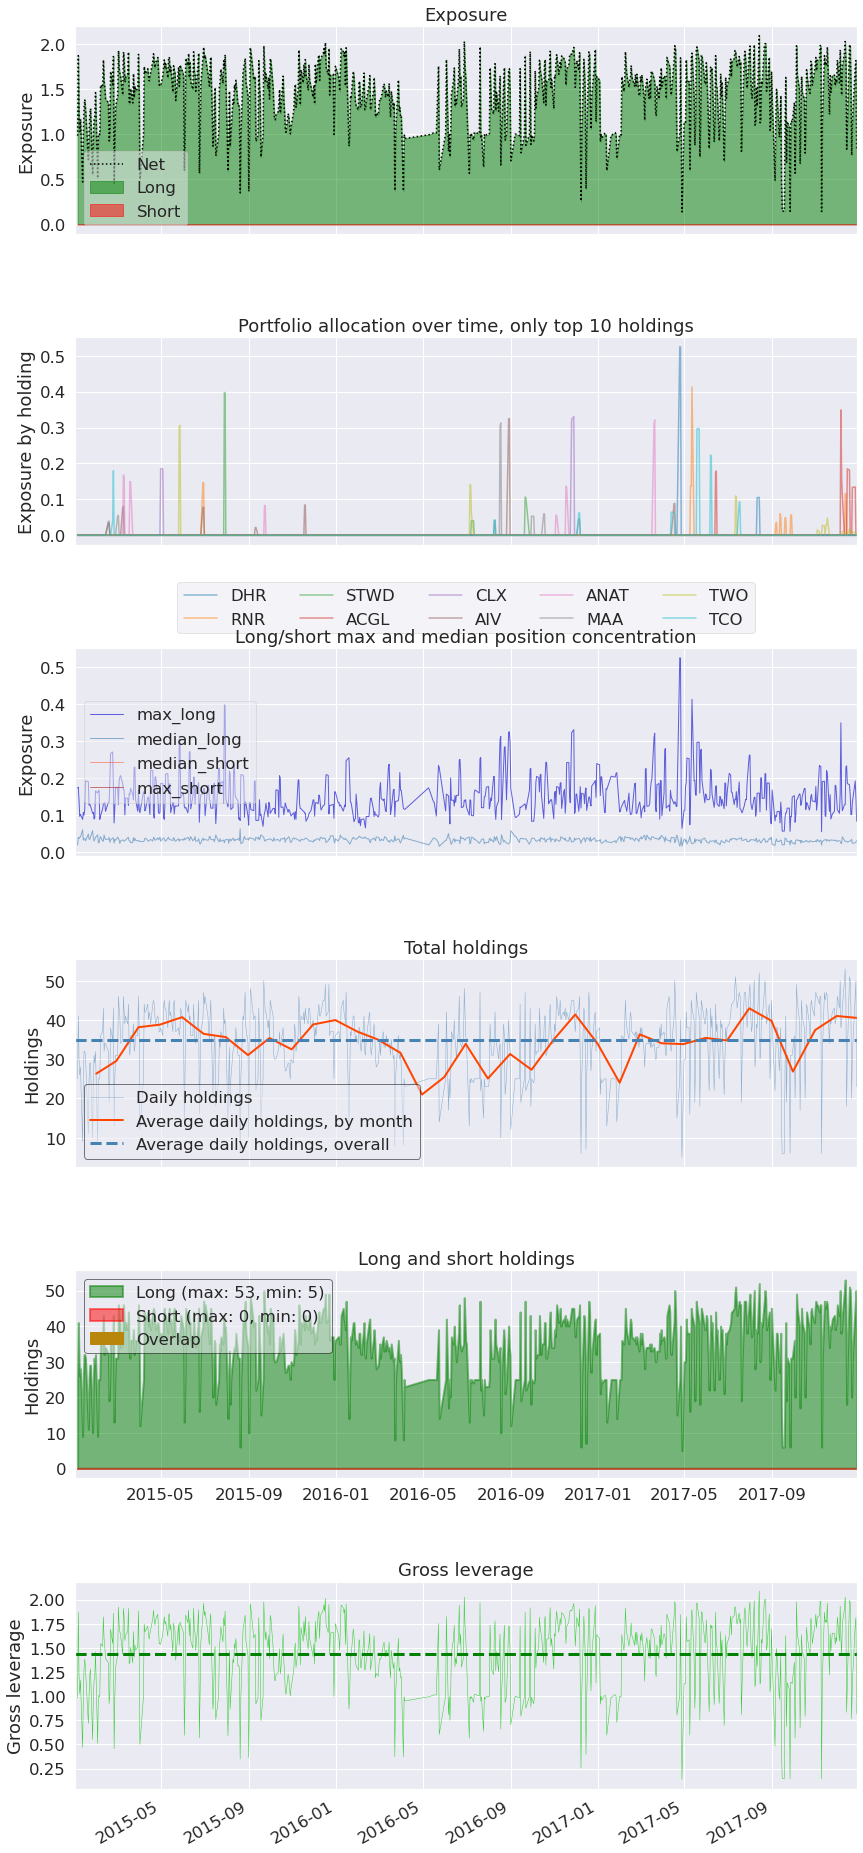

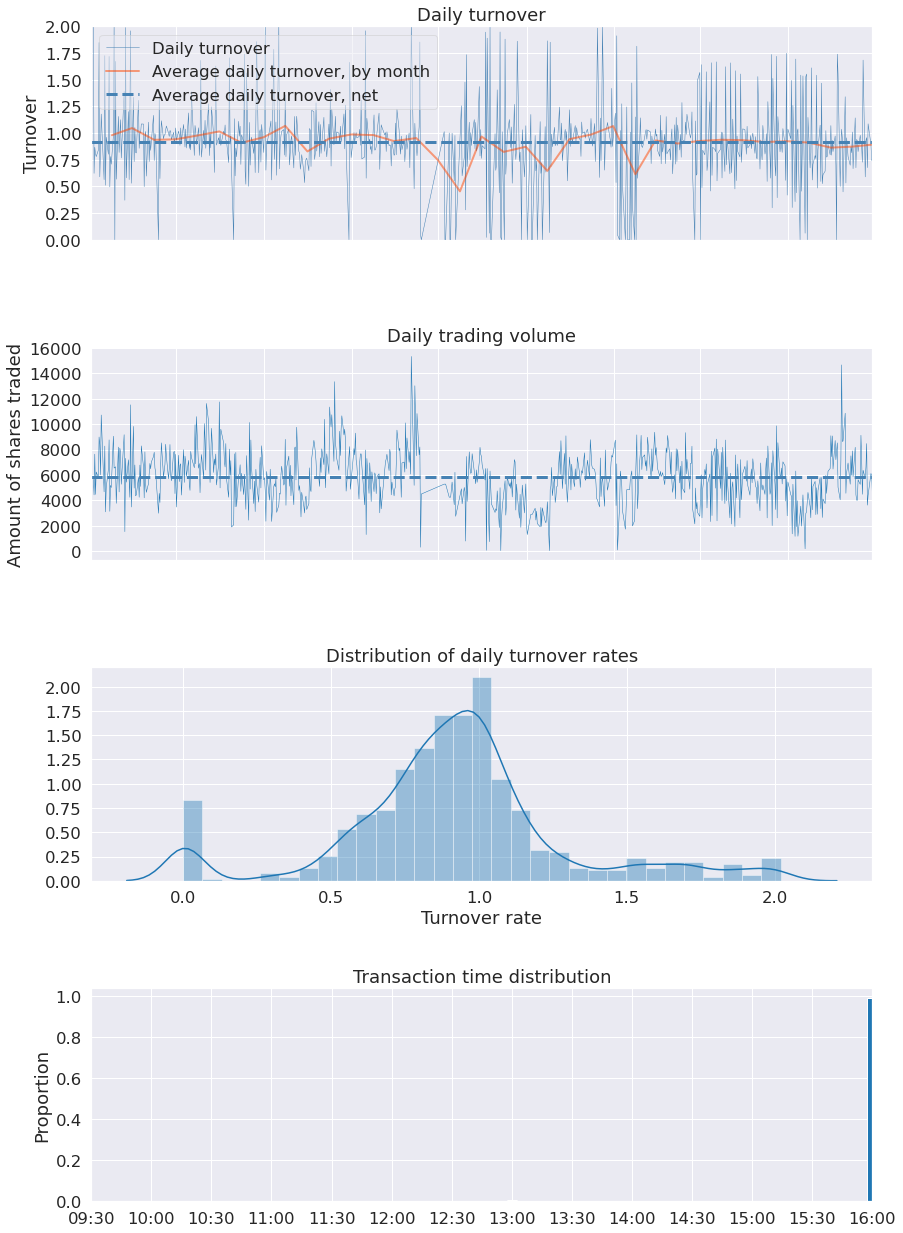

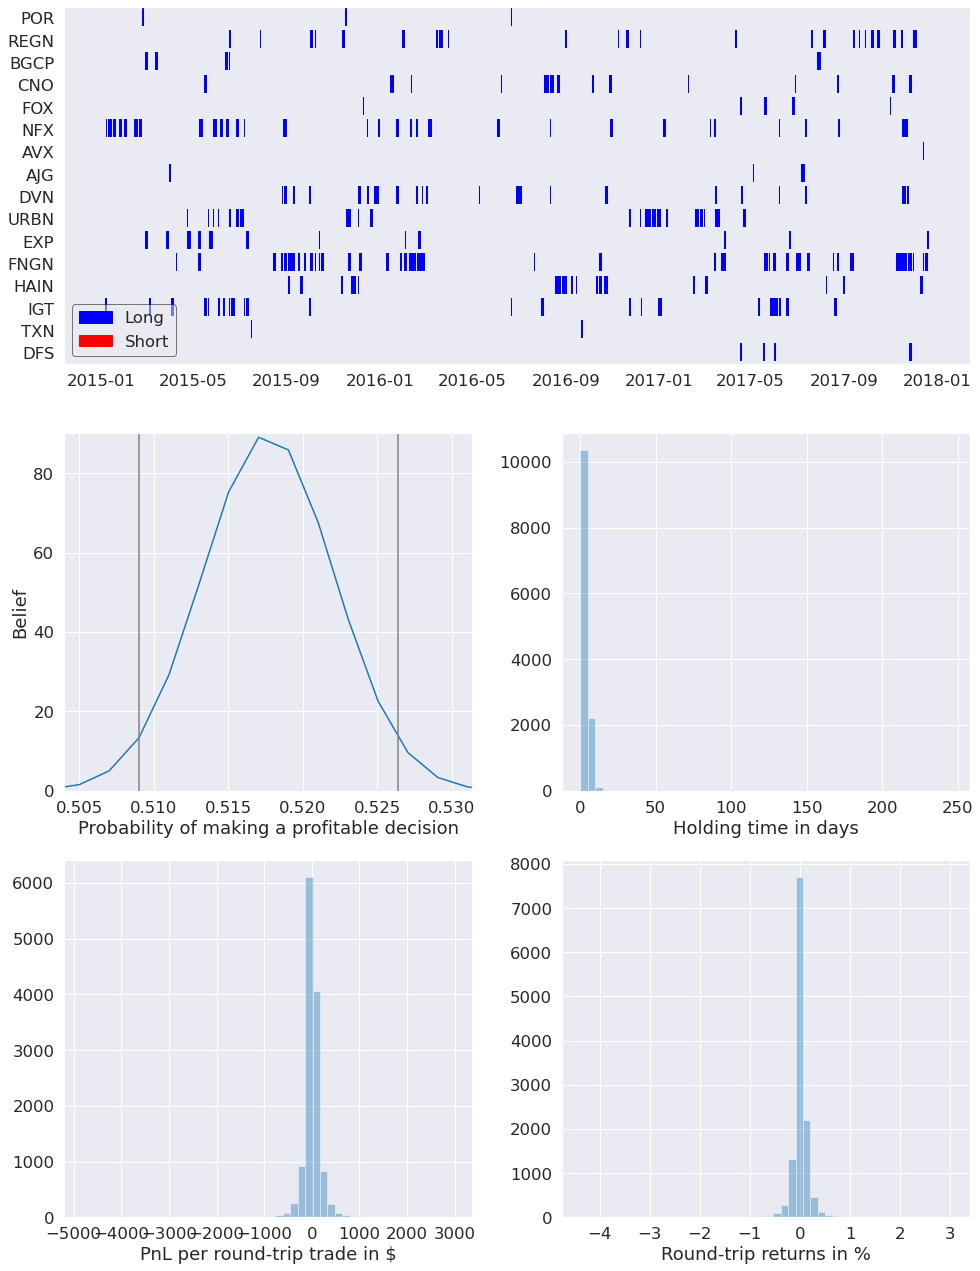

In [81]:
experiment = 'hrp'
returns, positions, transactions = load_results(experiment)

pf.create_full_tear_sheet(returns, 
                          positions=positions, 
                          transactions=transactions,
                          benchmark_rets=benchmark,
                          live_start_date='2017-01-01', 
                          round_trips=True)

#### Markowitz

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,45.42,2015-11-25,2016-02-08,2016-11-09,251
1,25.48,2015-08-04,2015-08-24,2015-10-15,53
2,20.35,2015-01-08,2015-01-30,2015-05-08,87
3,17.52,2015-10-15,2015-10-22,2015-11-18,25
4,15.24,2017-02-22,2017-04-13,2017-06-28,91


Stress Events,mean,min,max
Fall2015,-0.04%,-11.49%,10.77%
New Normal,0.21%,-11.49%,13.45%


Top 10 long positions of all time,max
sid,
EXEL,112.05%
GTT,110.58%
NVDA,110.47%
NFX,107.93%
AMD,107.33%
HRTX,105.11%
STMP,105.06%
NEM,105.00%
MGM,104.52%


Top 10 short positions of all time,max
sid,
THC,-0.03%
HXL,-0.03%
WOR,-0.03%
LM,-0.02%
HFC,-0.02%
AMED,-0.02%
WWW,-0.01%
SNV,-0.01%
STLD,-0.01%


Top 10 positions of all time,max
sid,
EXEL,112.05%
GTT,110.58%
NVDA,110.47%
NFX,107.93%
AMD,107.33%
HRTX,105.11%
STMP,105.06%
NEM,105.00%
MGM,104.52%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$281569.68,$-3.24,$281572.92
Gross profit,$1253052.67,$7.07,$1253045.60
Gross loss,$-971482.99,$-10.31,$-971472.68
Profit factor,$1.29,$0.69,$1.29
Avg. trade net profit,$124.37,$-0.15,$125.59
Avg. winning trade,$1053.87,$0.71,$1062.80
Avg. losing trade,$-914.77,$-0.86,$-925.21
Ratio Avg. Win:Avg. Loss,$1.15,$0.82,$1.15
Largest winning trade,$42403.45,$1.71,$42403.45
Largest losing trade,$-14966.87,$-5.64,$-14966.87


Duration stats,All trades,Short trades,Long trades
Avg duration,2 days 21:54:03.818021,2 days 14:10:54.545454,2 days 21:58:36.504906
Median duration,2 days 00:00:00,2 days 00:00:00,2 days 00:00:00
Longest duration,11 days 00:00:00,5 days 00:00:00,11 days 00:00:00
Shortest duration,0 days 03:00:01,1 days 00:00:00,0 days 03:00:01


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.07%,-0.00%,0.07%
Avg returns winning,0.62%,0.00%,0.63%
Avg returns losing,-0.56%,-0.00%,-0.57%
Median returns all round_trips,0.01%,-0.00%,0.01%
Median returns winning,0.23%,0.00%,0.24%
Median returns losing,-0.21%,-0.00%,-0.21%
Largest winning trade,15.32%,0.00%,15.32%
Largest losing trade,-9.62%,-0.00%,-9.62%


Symbol stats,AAL,AAN,AAP,AAPL,ABC,ABMD,ABT,ACC,ACGL,ADI,ADM,ADP,ADSK,AEL,AEO,AET,AFG,AFSI,AGCO,AGN,AGO,AIG,AIV,AIZ,AJG,AKAM,ALB,ALE,ALGN,ALK,ALKS,ALL,ALNY,AMAT,AMD,AME,AMED,AMGN,AMTD,AMZN,ANTM,AOS,ARE,ARRY,ASH,ATI,ATVI,AVGO,AVY,AWI,AWK,AYI,AZPN,B,BAH,BAX,BBT,BBY,BCO,BCPC,BDX,BECN,BG,BGCP,BID,BIDU,BIO,BK,BKH,BLKB,BMRN,BMY,BOFI,BOKF,BPOP,BR,BRKR,BSX,BWA,BYD,C,CACC,CACI,CAG,CAKE,CASY,CATY,CAVM,CB,CBU,CCE,CCL,CCMP,CCOI,CDNS,CELG,CERN,CF,CFR,CFX,CGNX,CHDN,CHE,CHFC,CHK,CHKP,CHTR,CI,CIT,CLF,CLGX,CLR,CMA,CMCSA,CNA,CNC,CNO,CNX,COG,COHR,COLM,COO,COR,CPA,CPRT,CPT,CREE,CRM,CSFL,CSGP,CSX,CTXS,CUBE,CVI,CXO,CXW,CY,DAL,DAN,DAR,DCI,DCT,DE,DECK,DEI,DG,DISH,DK,DKS,DLB,DLR,DLTR,DNB,DO,DPZ,DRE,DRI,DUK,DVN,DXCM,DY,EA,EBAY,EBIX,EBS,EE,EEFT,EFX,EGN,EIX,ELS,ENR,ENS,ENV,EPR,EQIX,EQR,ERIE,ESGR,ESV,EW,EXAS,EXC,EXEL,EXP,EXPE,EXPO,FCFS,FCX,FFBC,FFIV,FIBK,FICO,FIS,FIZZ,FL,FLO,FLT,FMBI,FNF,FNGN,FOLD,FR,FSLR,FTNT,FUL,FULT,GD,GDOT,GEO,GGP,GHC,GLNG,GM,GNRC,GOLD,GPN,GPT,GRMN,GT,GTT,GVA,HALO,HAS,HBI,HCSG,HE,HEI,HELE,HFC,HIG,HIW,HOLX,HPP,HPQ,HR,HRB,HRC,HRG,HRL,HRS,HRTX,HUM,HUN,HXL,IART,IBOC,ICE,ICUI,IDA,IDCC,IDTI,IDXX,IGT,IIVI,ILMN,IMMU,INCY,INTC,IPGP,IR,IRM,IRWD,ISRG,ITRI,ITT,JACK,JBL,JBLU,JBT,JCI,JCOM,JJSF,JNJ,JNPR,JPM,KBR,KEX,KLAC,KMT,KMX,KNX,KO,KRO,KS,KSS,KSU,LAMR,LANC,LB,LBTYA,LDOS,LECO,LGND,LHCG,LHO,LII,LLY,LM,LMT,LNG,LNT,LOGM,LPLA,LPX,LRCX,LSTR,LUV,LVS,LYV,MA,MAA,MAC,MAN,MANH,MAR,MASI,MDCO,MDR,MGM,MIDD,MKL,MKSI,MKTX,MLM,MMS,MMSI,MNST,MO,MOH,MPWR,MRVL,MS,MSA,MSCI,MSG,MTD,MTG,MTN,MTZ,MU,MYGN,MYL,NATI,NAV,NBIX,NCR,NDAQ,NDSN,NEE,NEM,NFLX,NFX,NHI,NI,NJR,NKE,NKTR,NNI,NOC,NRG,NSP,NTAP,NTRS,NUAN,NUS,NUVA,NVDA,NVR,NXST,O,OAS,OC,OHI,OKE,OLED,ONB,OPK,ORA,ORCL,OSK,OZRK,PBCT,PCG,PCH,PDCE,PEB,PEGA,PENN,PG,PGR,PHM,PII,PKG,PLD,PM,PNC,PNFP,PNM,PNW,PODD,POOL,PPC,PRI,PSA,PSB,PTEN,PWR,QCOM,QDEL,RCL,RDN,RE,REGN,RES,RF,RGLD,RHT,RJF,RMD,RNR,ROLL,ROP,ROST,RP,RTN,S,SAM,SATS,SBAC,SBRA,SBUX,SCG,SCI,SEB,SEE,SEIC,SEM,SFLY,SFNC,SGEN,SGMS,SHW,SIG,SIGI,SIRI,SIVB,SJM,SKX,SKYW,SLAB,SLGN,SM,SMG,SMTC,SNH,SNV,SNX,SON,SPG,SSNC,STL,STLD,STMP,STT,STX,STZ,SUI,SWKS,SWX,SYNT,SYY,T,TAL,TAP,TCBI,TECD,TECH,TEX,TFX,THC,THO,THS,TMO,TMUS,TREE,TREX,TRGP,TRI,TRMB,TRN,TROX,TSLA,TSN,TSS,TTC,TTEK,TTWO,TWO,TXN,TXRH,TYL,UAA,UAL,UBSH,UCBI,UDR,UFS,UHAL,ULTA,UMPQ,UNF,UNH,UNM,URBN,URI,USNA,UTHR,V,VAR,VC,VG,VMC,VMW,VR,VRNT,VRSK,VRSN,VRTX,VRX,VSH,WBA,WBC,WBS,WCG,WCN,WDC,WEN,WEX,WGL,WLL,WMB,WMT,WOR,WRB,WST,WTR,WWE,WWW,WYNN,X,XEL,XL,XPO,XRAY,YUM,ZBRA
Avg returns all round_trips,0.02%,-0.17%,-0.03%,-0.66%,-0.01%,0.78%,0.26%,-0.08%,0.03%,-0.25%,-0.10%,0.13%,-0.07%,0.01%,0.31%,5.28%,-0.88%,0.00%,0.74%,0.13%,0.25%,0.07%,-0.03%,0.25%,0.07%,-0.05%,0.84%,-0.07%,0.74%,0.10%,0.25%,0.71%,-0.38%,-0.37%,0.98%,0.03%,0.46%,0.01%,0.01%,-1.28%,-0.09%,0.07%,0.16%,-0.07%,0.01%,0.09%,1.30%,0.19%,-0.52%,nan%,-0.60%,0.78%,-2.71%,0.39%,0.15%,0.08%,0.06%,0.03%,0.47%,0.10%,0.24%,-0.06%,0.23%,0.32%,0.20%,-1.07%,-0.04%,0.28%,0.13%,0.29%,0.52%,-0.10%,-0.18%,0.01%,-0.16%,0.11%,0.00%,-0.34%,0.02%,-0.50%,-0.14%,0.13%,nan%,-0.27%,-0.42%,0.36%,0.07%,0.66%,-0.74%,0.82%,-0.06%,nan%,-0.07%,0.24%,0.25%,-0.52%,-0.47%,-0.00%,-0.03%,0.02%,-0.07%,-0.95%,0.08%,0.46%,0.09%,-0.14%,-0.11%,0.36%,-0.08%,-0.27%,-0.27%,2.18%,-0.00%,nan%,0.03%,0.20%,0.29%,-0.04%,-0.03%,-0.10%,0.22%,-0.56%,-0.33%,-0.09%,-0.31%,-1.31%,-0.41%,0.06%,0.09%,0.08%,-0.32%,0.90%,0.40%,-0.16%,-2.65%,-0.25%,0.08%,0.33%,1.57%,0.01%,0.08%,0.08%,-0.09%,0.92%,0.03%,-1.07%,-0.51%,-0.36%,0.49%,0.22%,-0.09%,-0.24%,-0.00%,-0.00%,0.33%,0.81%,0.23%,-0.35%,-0.43%,1.07%,-0.45%,-0.47%,-0.61%,0.04%,0.29%,-0.02%,0.22%,0.30%,0.60%,-0.16%,-0.57%,-0.01%,-0.00%,0.07%,-1.38%,-0.79%,-1.28%,-0.11%,-0.00%,-0.00%,-0.23%,-0.07%,-0.02%,0.14%,-0.03%,0.04%,-0.20%,-0.02%,-0.70%,0.03%,-1.39%,0.34%,-0.41%,nan%,0.41%,0.13%,0.42%,-0.25%,0.05%,0.10%,0.08%,-0.04%,0.18%,-0.08%,0.18%,nan%,0.00%,-0.22%,0.46%,-0.09%,0.01%,-0.15%,0.04%,-0.33%,-0.21%,0.03%,-0.08%,0.48%,nan%,3.76%,-0.28%,nan%,-0.26%,0.08%,-0.05%,0.04%,0.14%,nan%,-0.01%,0.00%,-1.18%,0.48%,2.35%,0.43%,0.18%,-0.92%,0.04%,-0.37%,0.62%,-0.25%,0.02%,0.96%,-1.74%,-0.12%,0.00%,

Profitability (PnL / PnL total) per name,
symbol,
IMMU,18.33%
AMD,15.92%
SGMS,11.95%
HRTX,11.37%
ABMD,6.08%
DXCM,5.92%
TAL,5.73%
AET,5.63%
X,5.44%


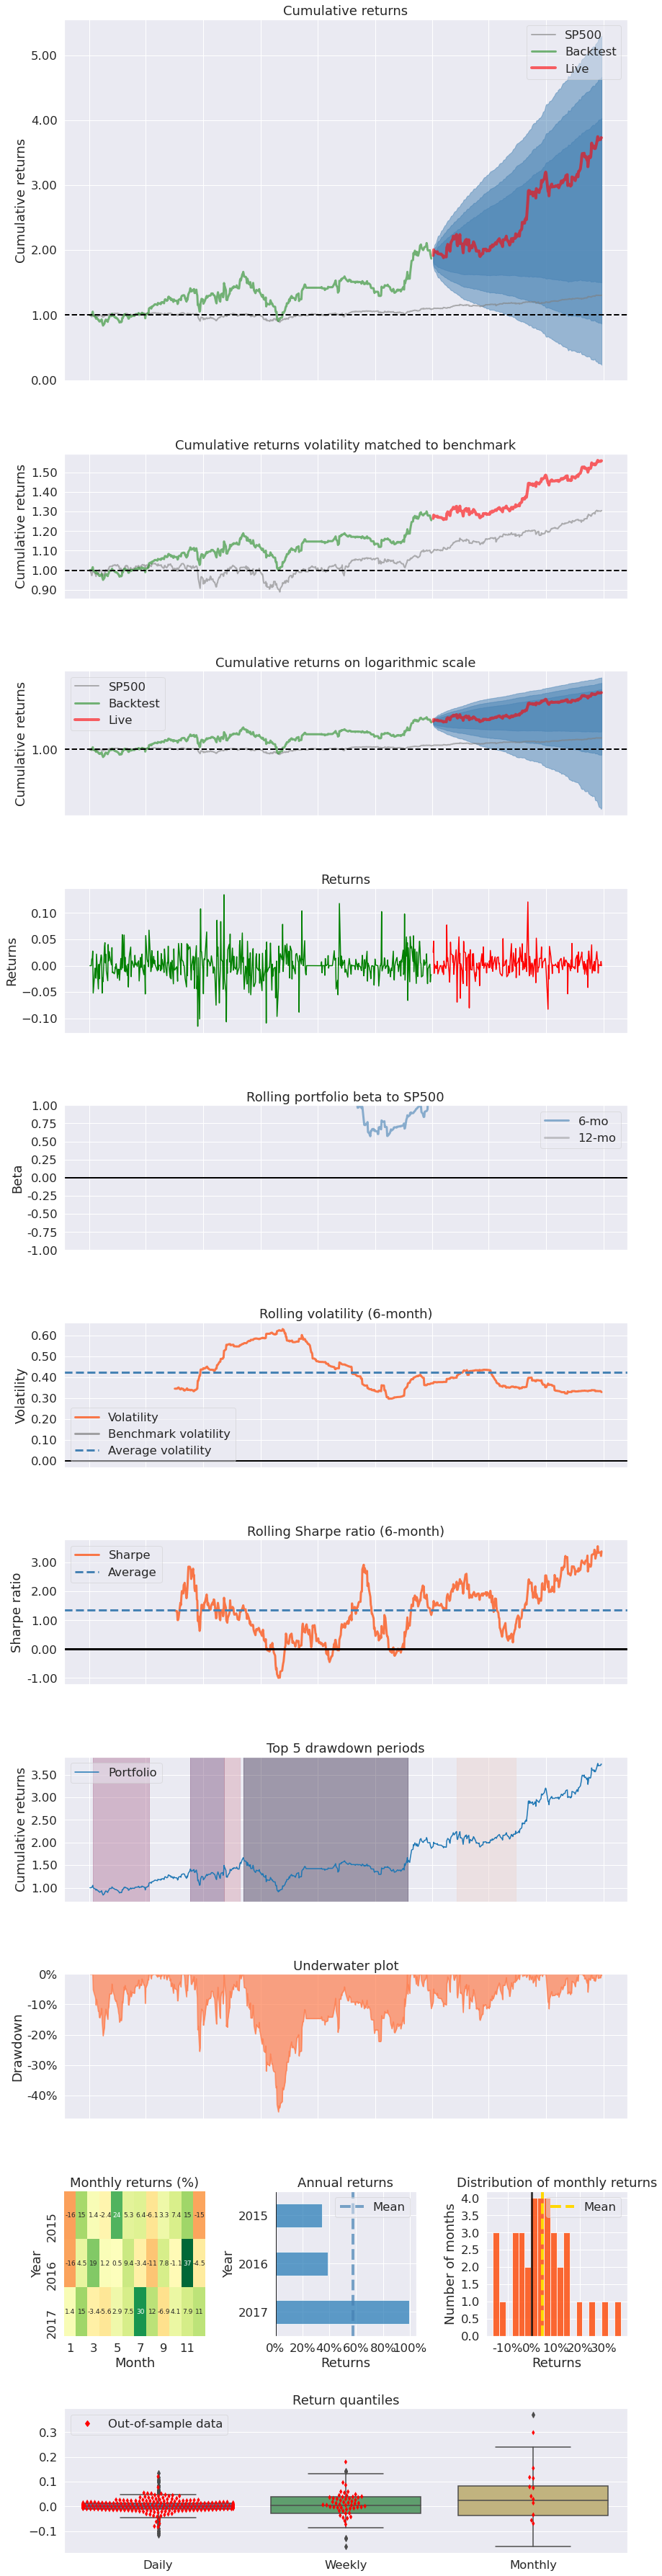

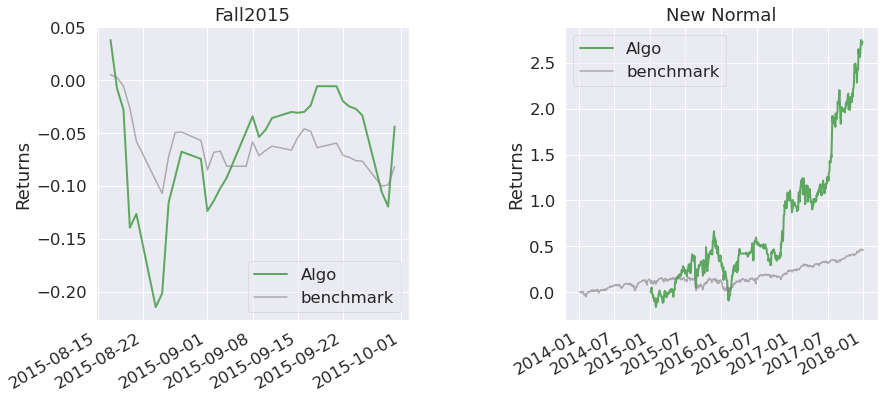

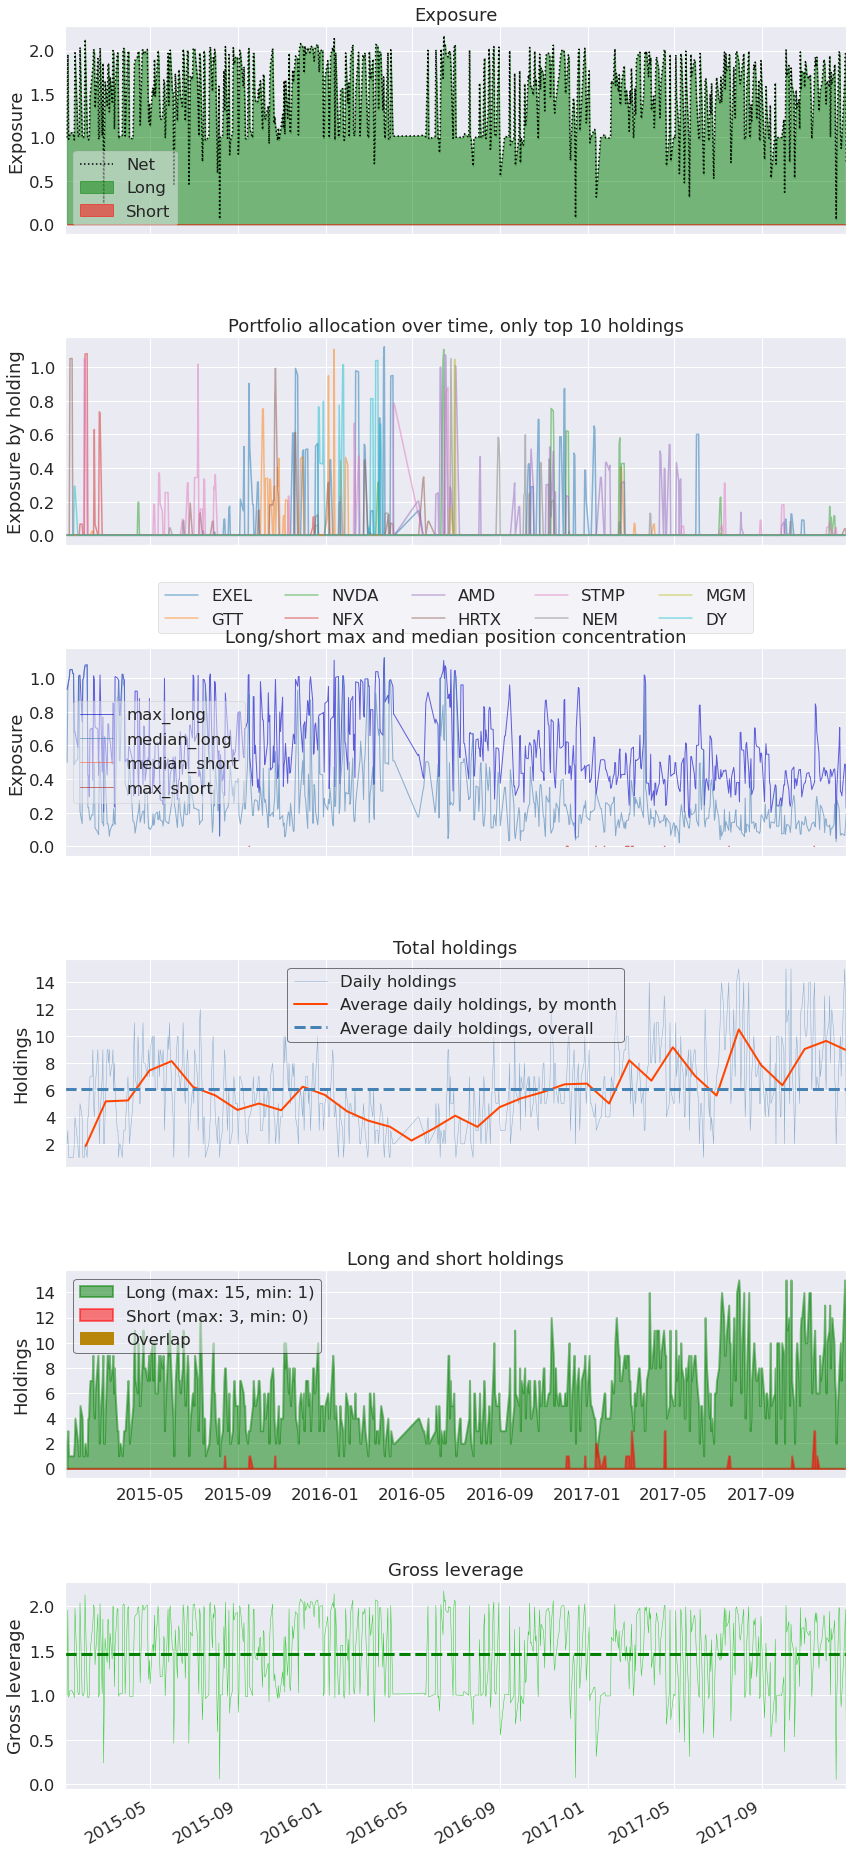

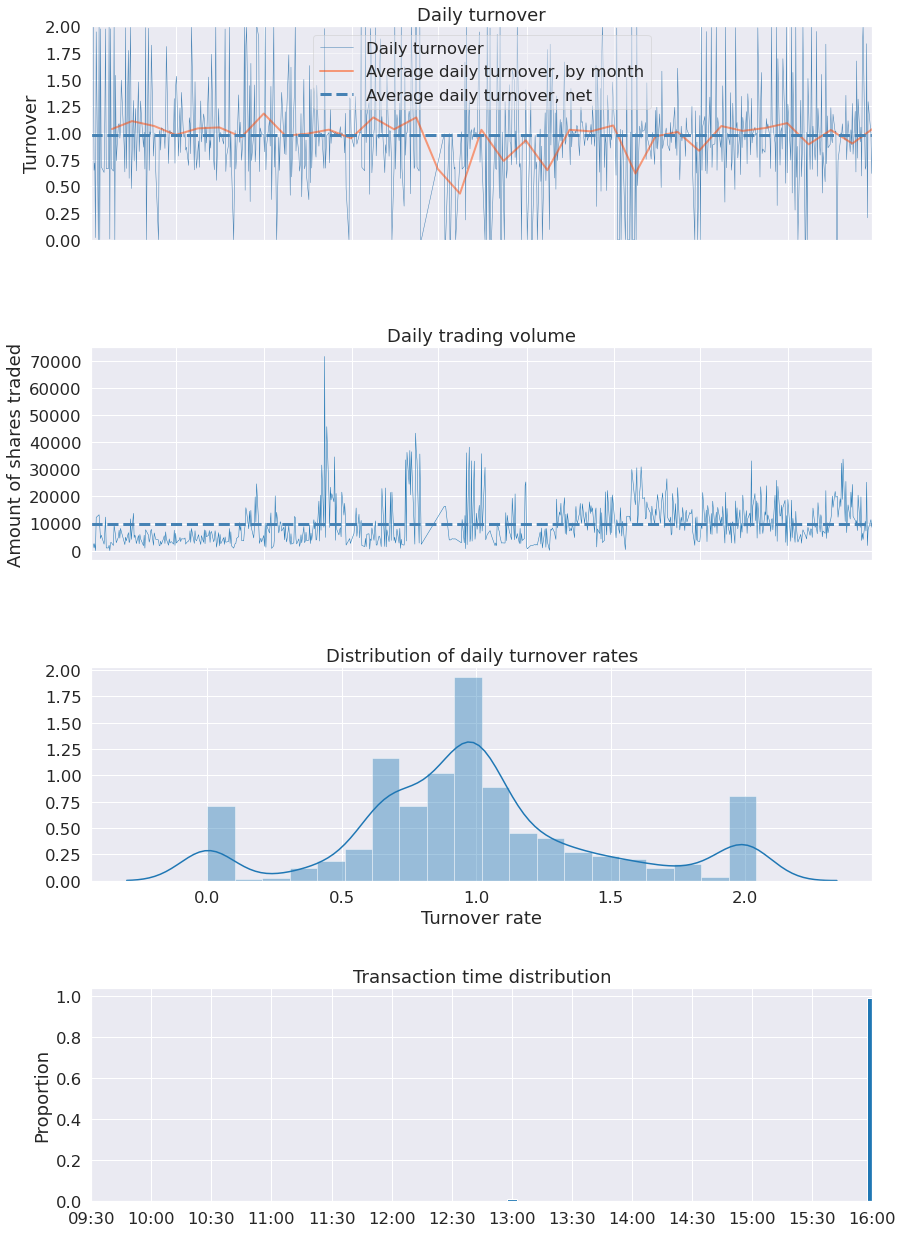

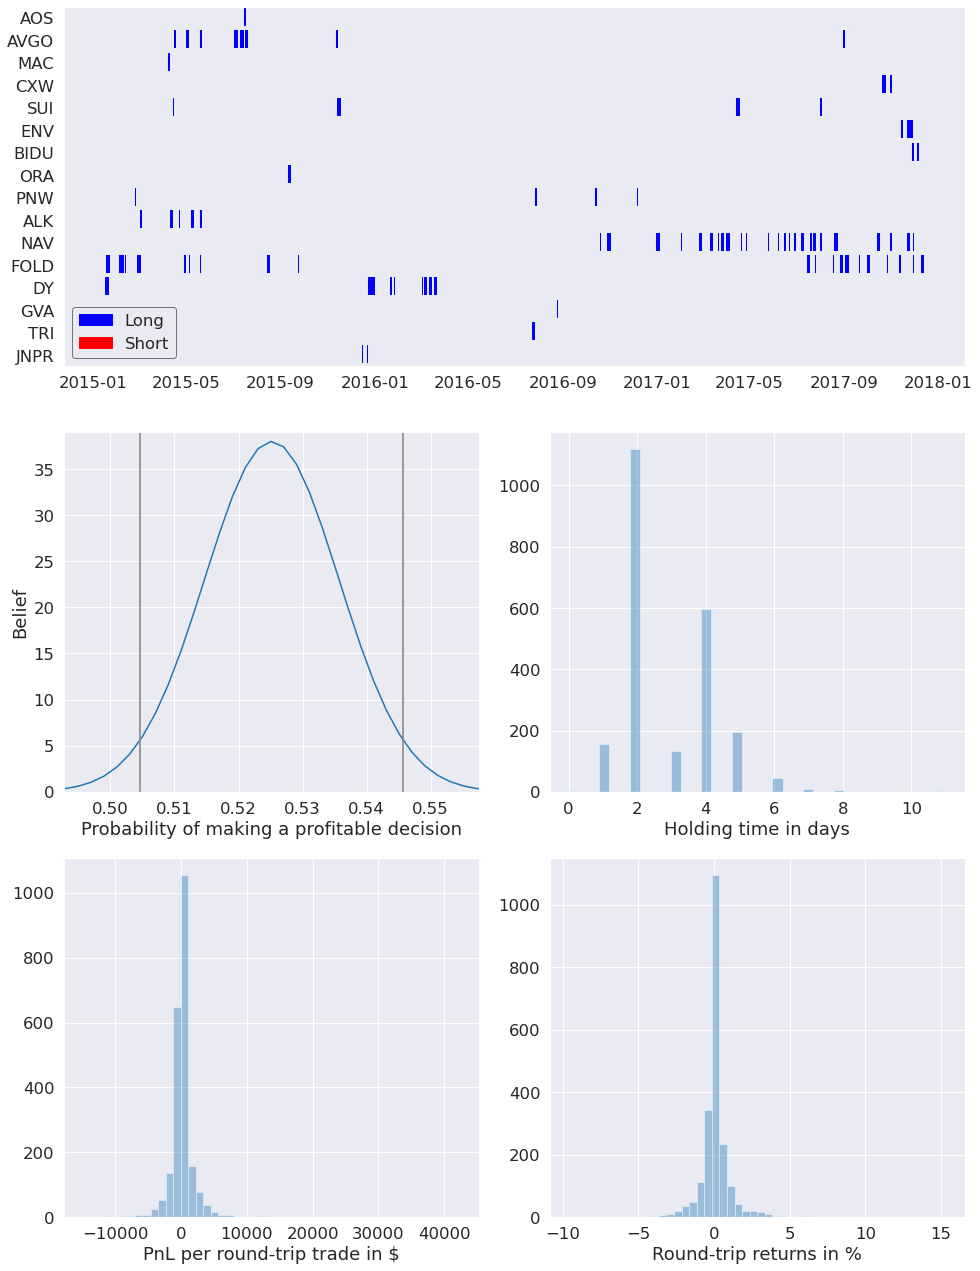

In [82]:
experiment = 'markowitz'
returns, positions, transactions = load_results(experiment)

pf.create_full_tear_sheet(returns, 
                          positions=positions, 
                          transactions=transactions,
                          benchmark_rets=benchmark,
                          live_start_date='2017-01-01', 
                          round_trips=True)